Alexander W. Criswell 1/28/26

Final notebook for computing SNRs and prospects for low-frequency multiband MBHB observations via the PTA orphaned pulsar term.

In [1]:
%load_ext autoreload
%autoreload 2

In [84]:
from __future__ import division

%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import matplotlib
from matplotlib import pyplot as plt
from matplotlib.ticker import NullFormatter
from matplotlib.lines import Line2D
from matplotlib import patches
from matplotlib.patches import Patch
from mpl_toolkits.axes_grid1 import make_axes_locatable
#matplotlib.rcParams['savefig.dpi'] = 1.5 * matplotlib.rcParams['savefig.dpi']

import os, glob, time, sys, functools
import corner
import numpy as np

import scipy
import scipy.constants as sc
import scipy.integrate as si
import scipy.signal as ssig
import scipy.interpolate as scint
import scipy.linalg as sl
import scipy.stats as st

from tqdm import tqdm

## astrpy imports
import astropy.constants as const
import astropy.coordinates as cc
import astropy.units as u
import astropy_healpix as ahp
from astropy_healpix import healpy as hp
import healpy as hp_old

## import our code
import PhenomA as pa
import observatories as obs
import WaveformTools as wt
import utils

In [3]:
## set the plotting style
utils.set_style()

## Preliminaries

In [4]:
## load the rates and bins from the Milano group
logz_bins = np.loadtxt('./data/Bins_logRedshift.txt')
logM_bins = np.loadtxt('./data/Bins_logMass.txt')
rates = np.loadtxt('./data/d3N_dlogMdlogzdt_LGalaxies.txt')

In [5]:
rates.shape, logz_bins.shape

((77, 175), (78,))

In [6]:
logz_bin_mids = logz_bins[1:] - (logz_bins[1]-logz_bins[0])/2
logM_bin_mids = logM_bins[1:] - (logM_bins[1]-logM_bins[0])/2

## Rates Plots

/tmp/ipykernel_154380/3671508646.py:2: RuntimeWarning: divide by zero encountered in log10
  plt.contourf(logM_bin_mids,10**logz_bin_mids,np.log10(rates),cmap='cool',levels=np.linspace(-3,0,7))


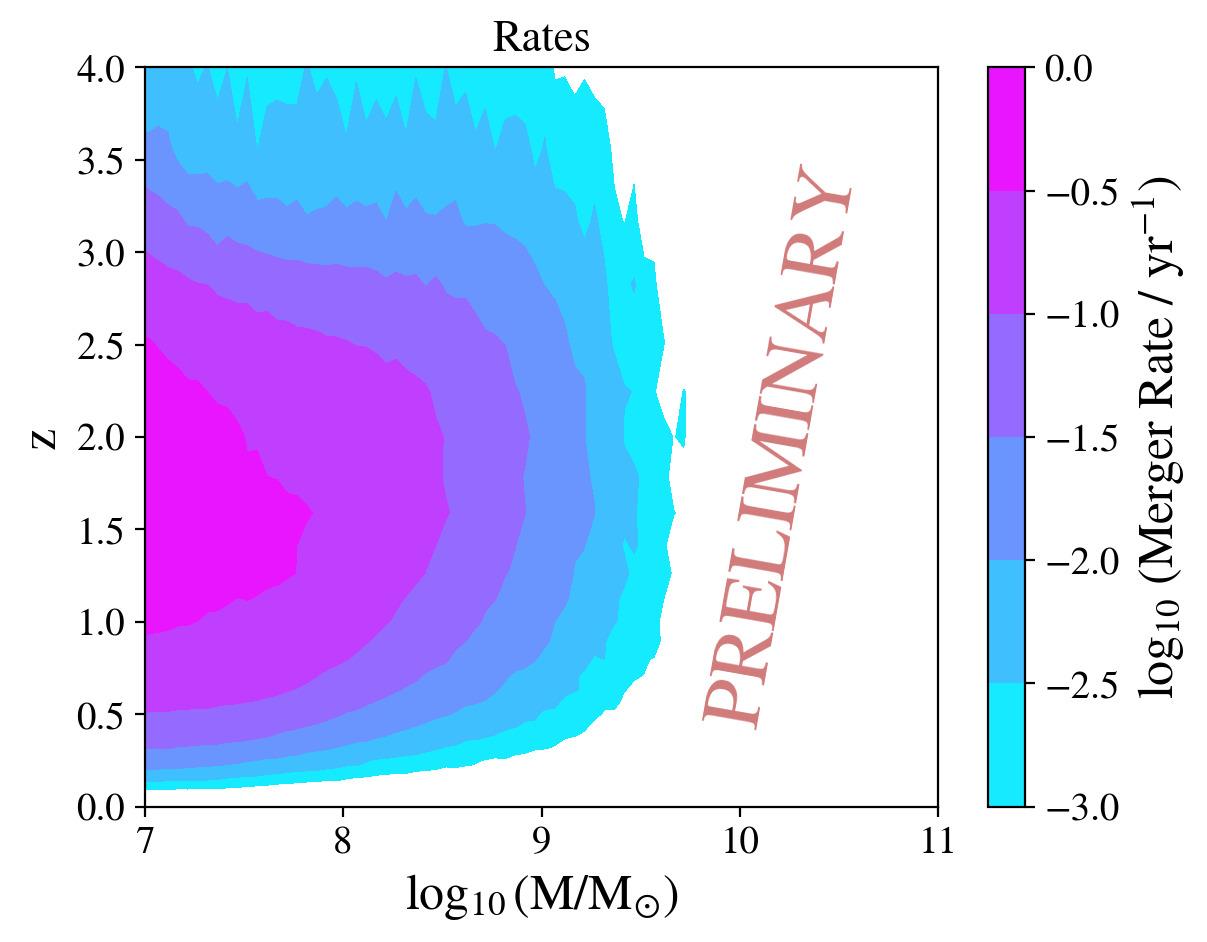

In [7]:
plt.figure()
plt.contourf(logM_bin_mids,10**logz_bin_mids,np.log10(rates),cmap='cool',levels=np.linspace(-3,0,7))
cbar = plt.colorbar()
cbar.ax.set_ylabel('log$_{10}$ (Merger Rate / yr$^{-1})$',fontsize=18)
plt.xlabel(r'$\log_{10}(\mathrm{M/M_{\odot}})$',fontsize=18)
plt.ylabel('z',fontsize=18)
plt.ylim(0,4)
plt.xlim(7,11)
plt.title("Rates")
plt.text(9.8,0.5,"PRELIMINARY",fontsize=30,color='firebrick',alpha=0.6,rotation=80)
plt.show()

In [8]:
## integrate over redshift
rates_zint = np.sum(rates*(logz_bins[1:]-logz_bins[:-1])[:,None],axis=0)

Total rate as a function of mass:

/tmp/ipykernel_154380/3589364358.py:2: RuntimeWarning: divide by zero encountered in log10
  plt.plot(logM_bin_mids,np.log10(rates_zint),lw=3)


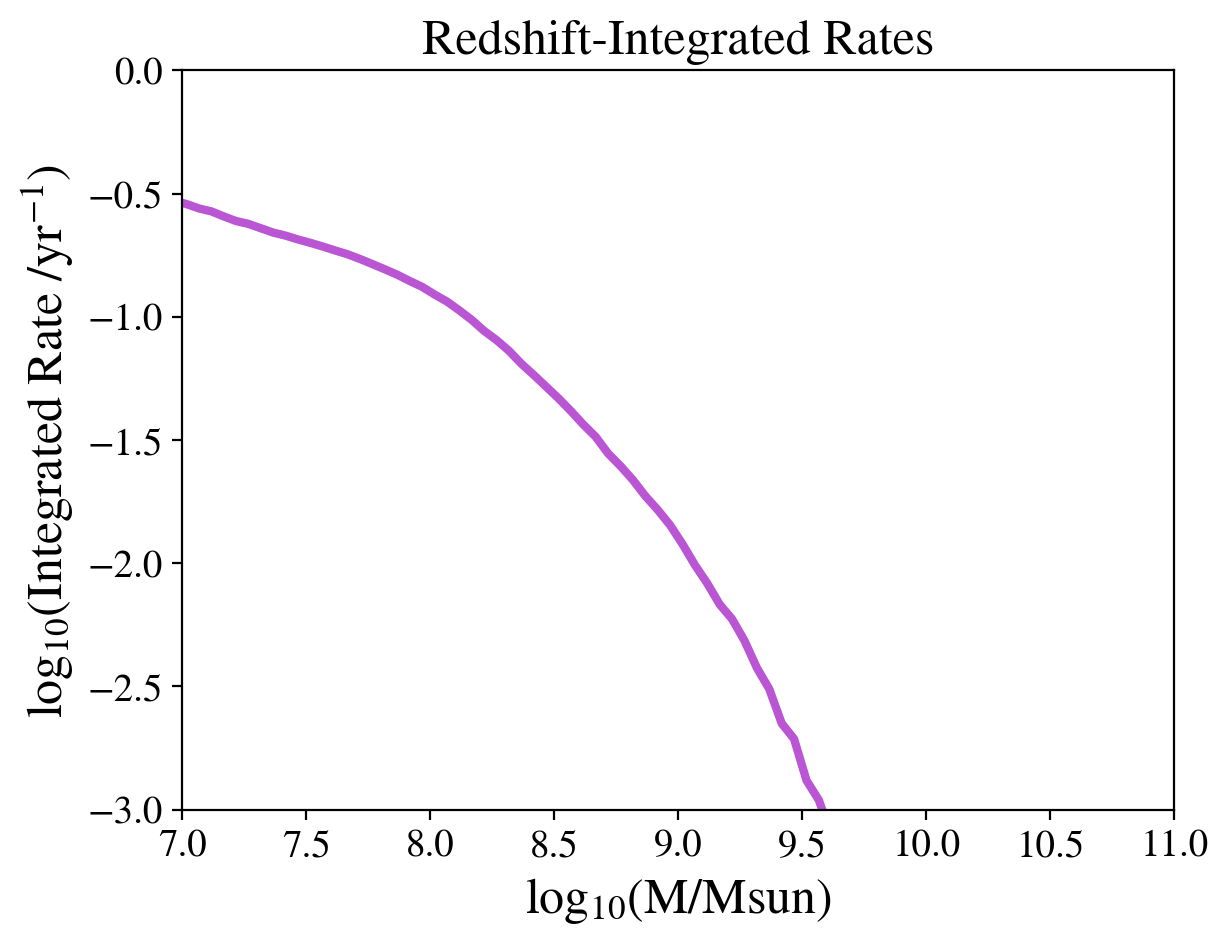

In [9]:
plt.figure()
plt.plot(logM_bin_mids,np.log10(rates_zint),lw=3)
plt.xlabel('log$_{10}$(M/Msun)',fontsize=18)
plt.ylabel('log$_{10}$(Integrated Rate /yr$^{-1}$)',fontsize=18)
plt.ylim(-3,0)
plt.xlim(7,11)
plt.title("Redshift-Integrated Rates",fontsize=18)
plt.show()

Look at the cumulative rates:

In [10]:
## log total mass bin width
logM_bins[1] - logM_bins[0]

0.050000000000000044

In [11]:
## above 10^9 Msun
gtr1e9 = logM_bin_mids>9.0
rates_fullint = np.sum(rates_zint[gtr1e9]*(logM_bins[1:] - logM_bins[:-1])[gtr1e9])

In [12]:
print(rates_fullint)

0.003189766799400277


In [13]:
## integrated rates, cumulative descending
ircd = np.cumsum((rates_zint*(logM_bins[1:] - logM_bins[:-1]))[::-1])

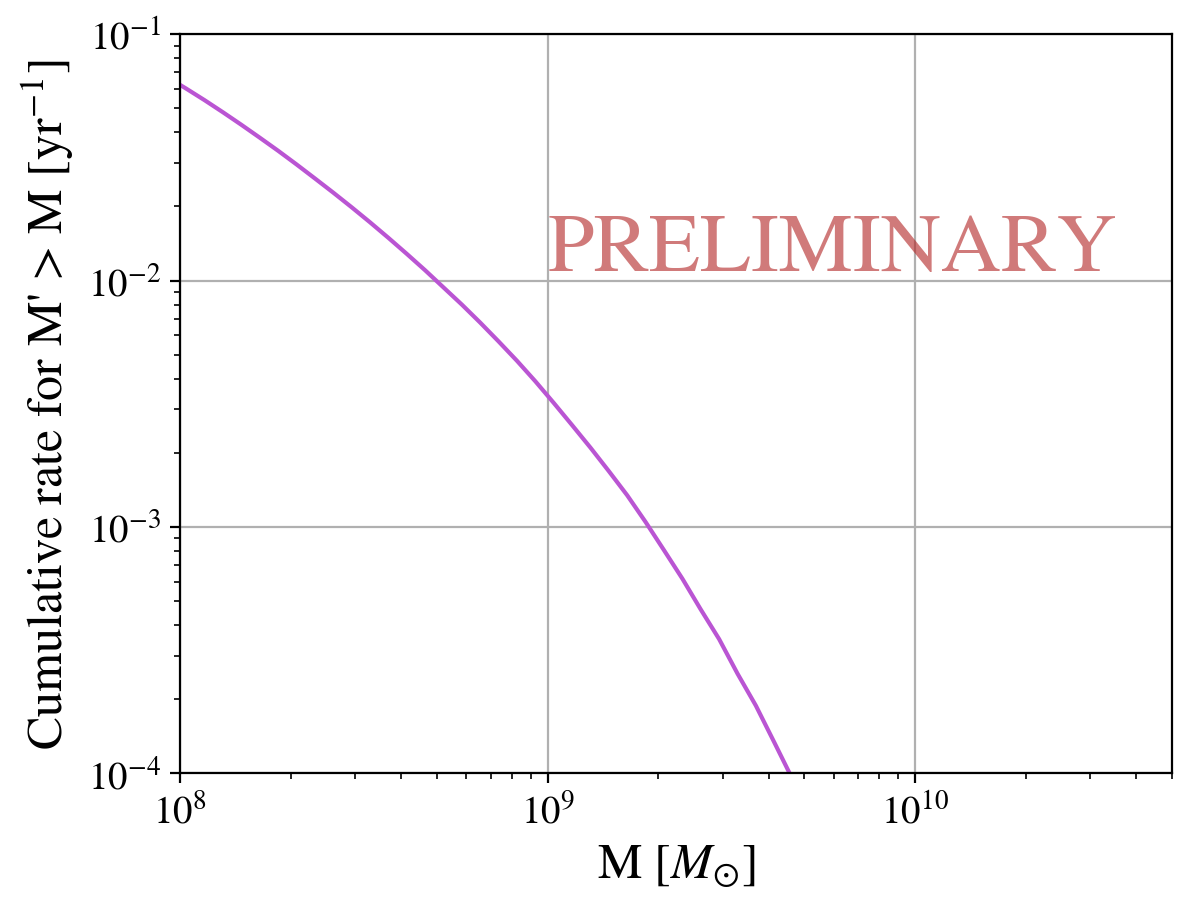

In [14]:
plt.figure()
plt.loglog(10**logM_bin_mids[::-1],ircd)
plt.xlabel(r'M [$M_{\odot}$]',fontsize=18)
plt.ylabel("Cumulative rate for M' > M [yr$^{-1}$]",fontsize=18)
plt.ylim(1e-4,1e-1)
plt.xlim(1e8,5e10)
plt.grid()
plt.text(1e9,0.011,"PRELIMINARY",fontsize=30,color='firebrick',alpha=0.6)
plt.show()

## Observatories

The below code instantiates the observatory objects for LISA, ${\rm \mu}$Ares, and the two astrometric experiments.

In [15]:
muAres_snfile = 'strain_sens_ARES_instrument.txt'

In [16]:
muAres = obs.Observatory("muAres",4*u.yr,sens_curve=muAres_snfile)

In [17]:
lisa = obs.LISA() 

In [18]:
kepler = obs.Astrometry("Kepler")

In [19]:
roman = obs.Astrometry("Roman")

In [20]:
dr3like = obs.OrphanArray(nside=16)

Loading Enterprise pulsars...
PSR B1855+09 complete [tempo2Util.C:396] Warning: [MISC1] Unknown parameter in par file:  DMDATA
[tempo2Util.C:401] Warning: [DUP1] duplicated warnings have been suppressed.
[tempo2Util.C:396] Warning: [PAR2] Have not set a DM epoch. The period epoch will be used instead. B1855+09.par
PSR J2322-2650 complete   
Timespan: 22.2 yrs

Computing correlations...
PSR J2322-2650 complete   
Creating hasasia spectra...
PSR J2322-2650 complete   

In [21]:
len(dr3like.psrs)

116

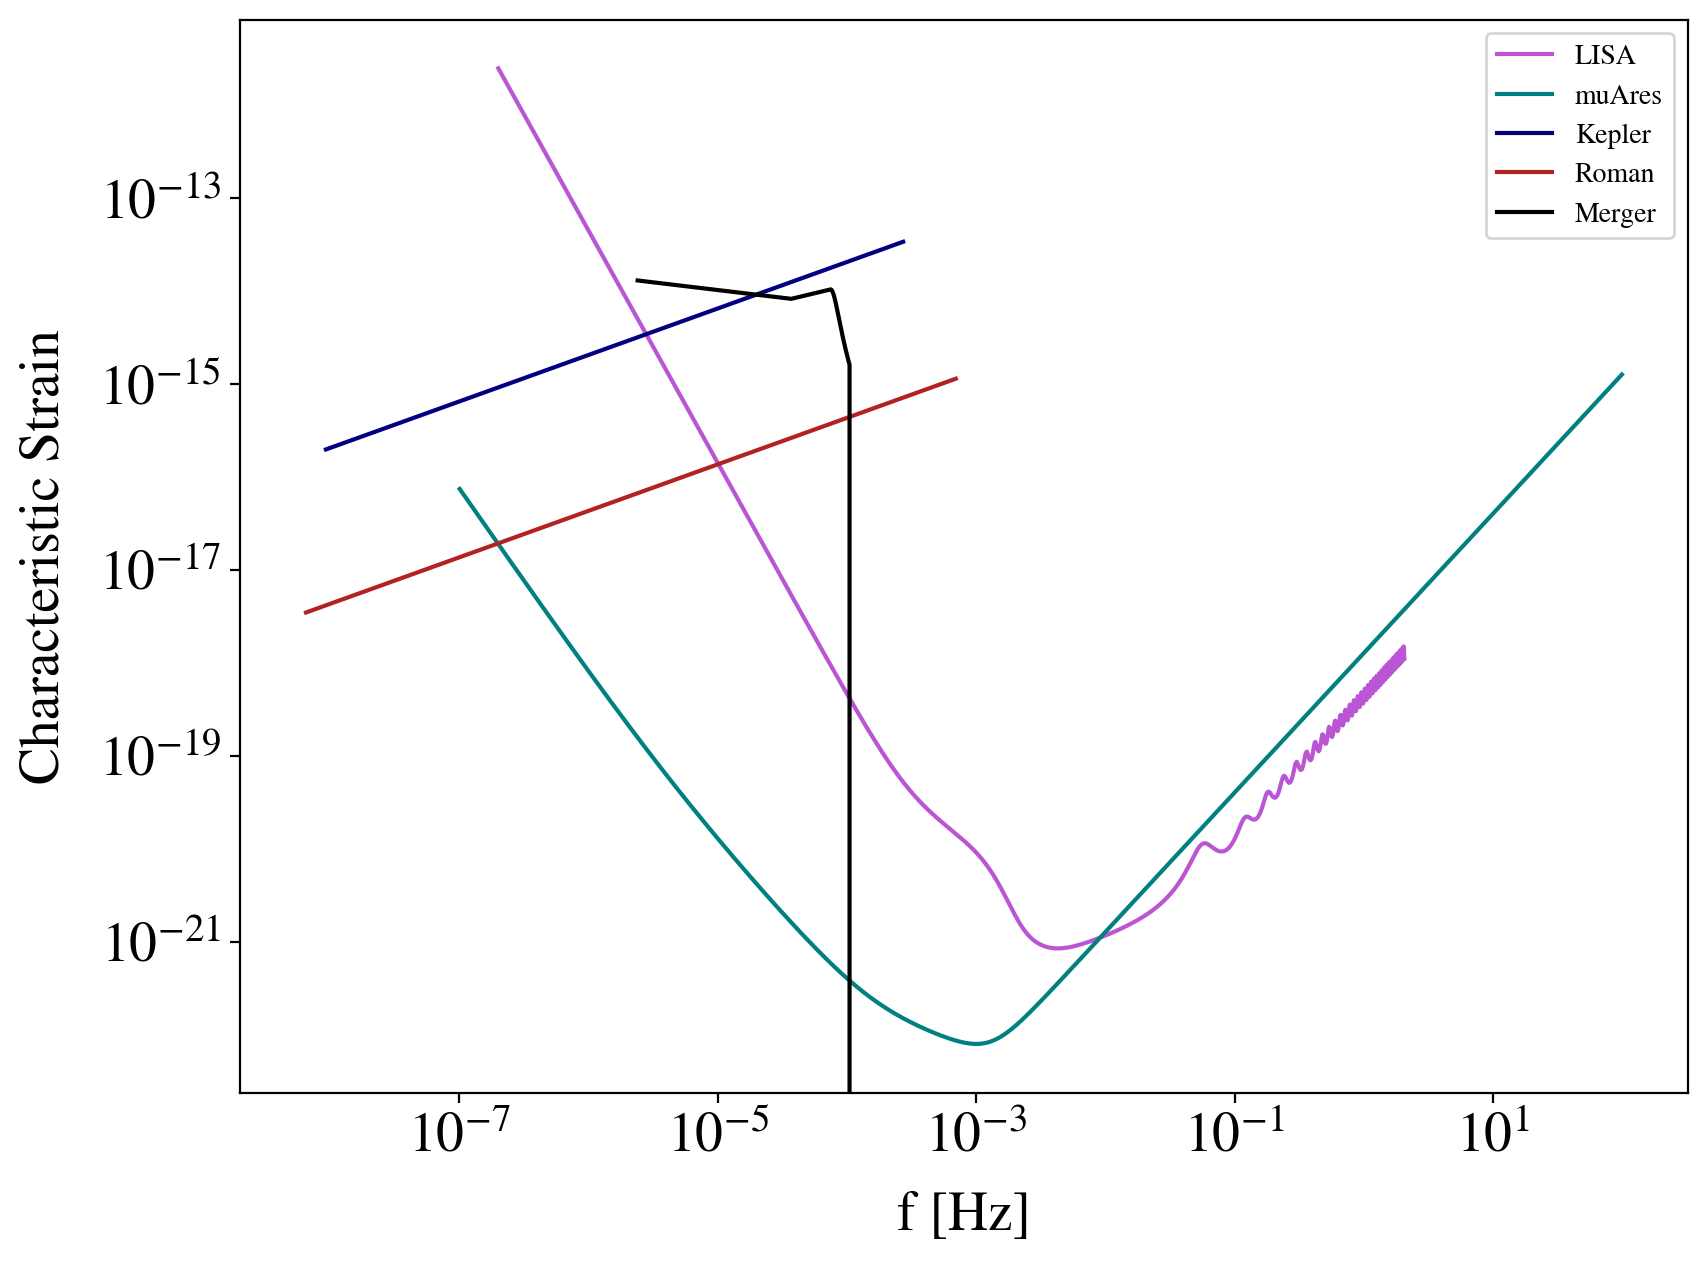

In [22]:
ax = obs.plot_multi_obs_sensitivity([lisa,muAres,kepler,roman],show=False)
binary = wt.Binary(1e8,1e8,z=0.1)
T_merge = 1*u.yr
binary.T_merge = T_merge.to(u.s)
binary.SetFreqBounds(muAres)
freqs, hc = binary.CalcStrain(muAres)
binary.add_strain_to_plot(ax, freqs, hc,color='k',label='Merger')
plt.legend()
plt.show()

## Time-Delay and Frequency Shift Across Array

In [60]:
extent = dr3like.pdist_extent

In [51]:
## use astropy to transform pulsar locations to galactocentric XYZ
## psr [theta, phi] are colatitude, longitude
psr_lats = [(psr.theta-np.pi/2)*u.rad for psr in dr3like.psrs]
psr_longs = [(psr.phi)*u.rad for psr in dr3like.psrs]
skycoords = cc.SkyCoord(lat=psr_lats,
                        lon=psr_longs,
                        distance=dr3like.pulsar_distances,
                        frame='barycentricmeanecliptic')

In [55]:
## swap to cylindrical representation for plot
skycoords.representation_type = 'cylindrical'

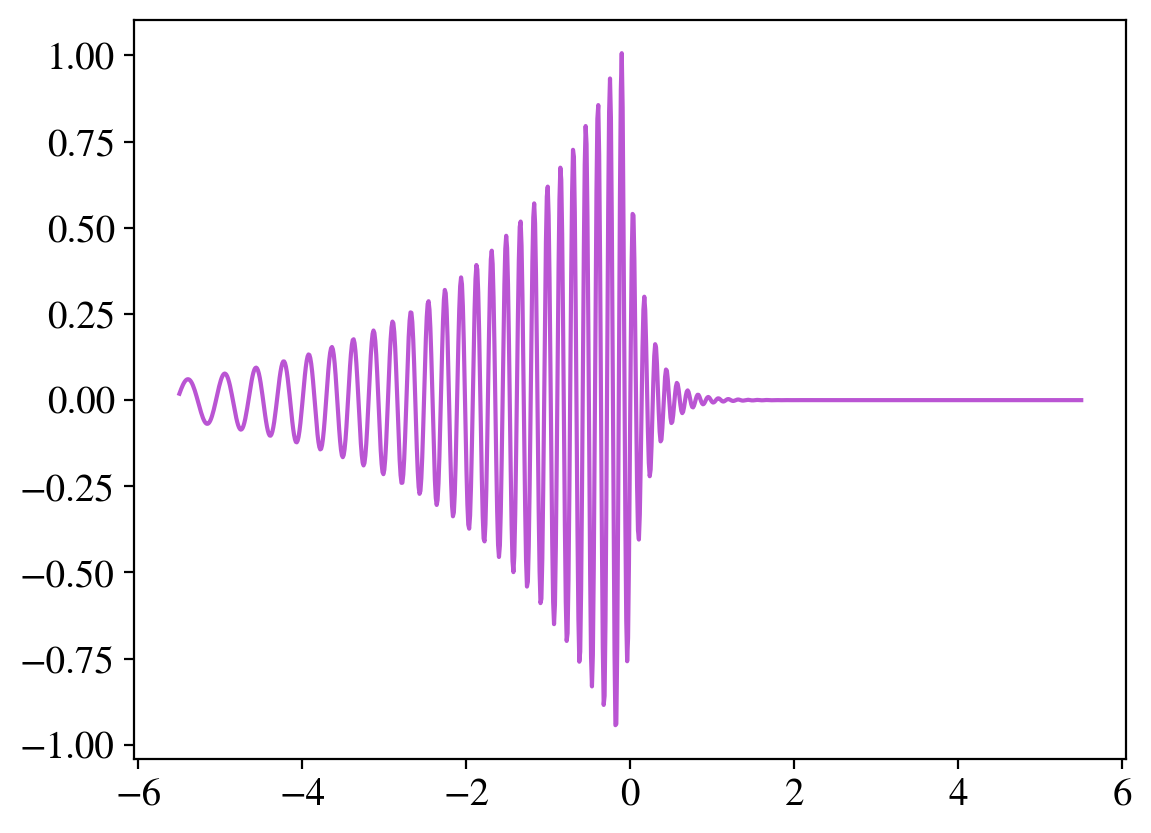

In [62]:
## silly little schematic waveform
plot_waveform_xs = np.linspace(-1.1*extent.value,1.1*extent.value,1000)
merger_x = -.1
damp_fac = np.array([1 if x<=merger_x else np.exp(-5*(x-merger_x)) for x in plot_waveform_xs])
plot_waveform_ys = 0.075*(1.7**(plot_waveform_xs+5))*np.sin(((plot_waveform_xs+15)*3) * plot_waveform_xs)\
                        *damp_fac
plt.figure()
plt.plot(plot_waveform_xs,plot_waveform_ys)
plt.show()

v1 with actual (simulated) pulsar positions:

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


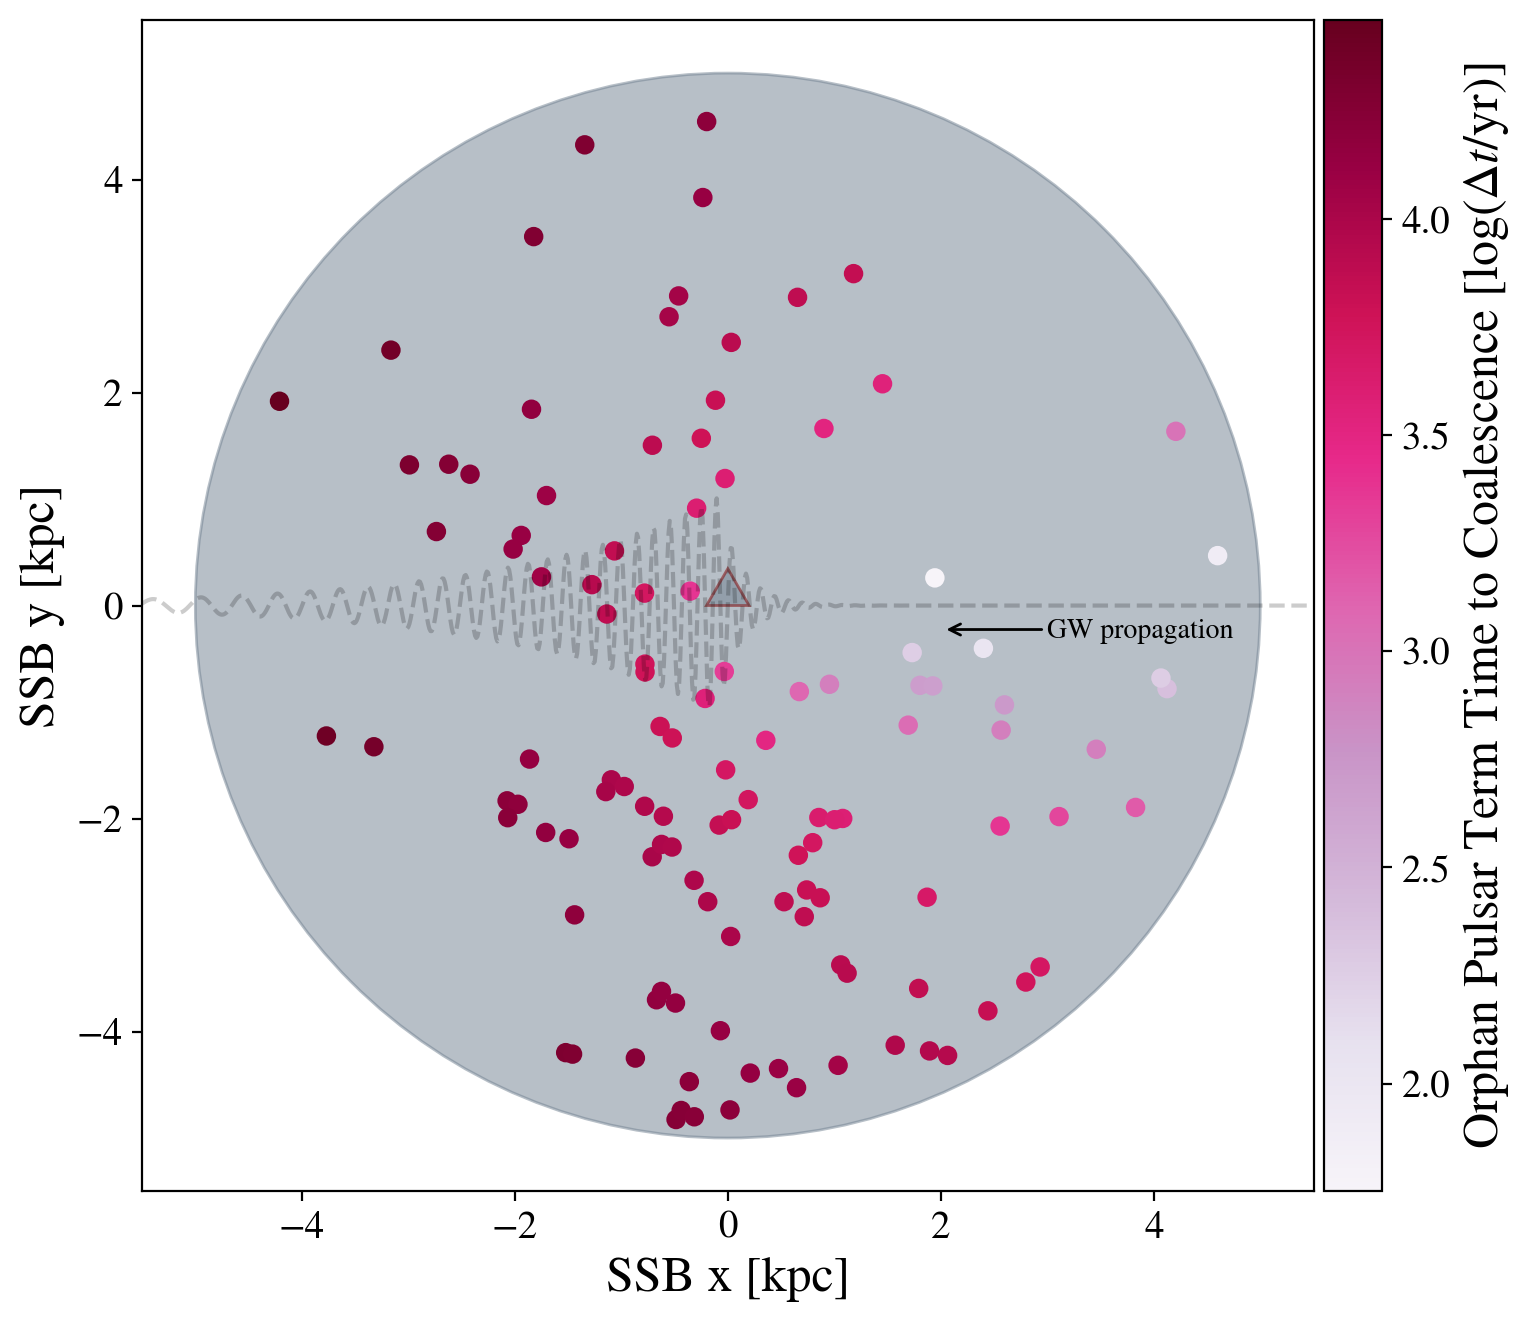

In [94]:

plot_extent = (extent + 0.1*extent).value
plt.figure(figsize=(8,8))
plt.plot(plot_waveform_xs,plot_waveform_ys,color='k',alpha=0.2,ls='--')
plt.gca().annotate("", xytext=(3,-.225), xy=(2,-.225),
            arrowprops=dict(arrowstyle="->"))
plt.text(3,-.3,"GW propagation")
plt.gca().add_patch(patches.Circle((0,0),extent.value,color='slategrey',alpha=0.5))
plt.gca().add_patch(patches.Polygon(np.array([[0,0.2*np.sqrt(3)],[0.2,0],[-0.2,0]]),
                                    edgecolor='maroon',facecolor='slategrey',alpha=0.5))
plt.scatter((skycoords.rho*np.cos(skycoords.phi.to(u.rad))).value,
            (skycoords.rho*np.sin(skycoords.phi.to(u.rad))).value,
            c=np.log10((skycoords.rho/const.c).to(u.yr).value*(1-np.cos(skycoords.phi.to(u.rad)))),
            cmap='PuRd')#,vmin=0,vmax=250000)
plt.xlim(-plot_extent,plot_extent)
plt.ylim(-plot_extent,plot_extent)
plt.xlabel("SSB x [kpc]",fontsize=18)
plt.ylabel("SSB y [kpc]",fontsize=18)
plt.gca().set_aspect('equal')
# plt.title('Echo Delay Map',fontsize=22)
divider = make_axes_locatable(plt.gca())
cax = divider.append_axes("right", size="5%", pad=0.05)
cb = plt.colorbar(cax=cax)
cb.set_label(label='Orphan Pulsar Term Time to Coalescence [log($\\Delta t$/yr)]',fontsize=18)
utils.savefig('time_delay_diagram_realistic',saveto='./figures/paper_figures/')
# plt.savefig("./figures/paper_figures/time_delay_map.png",dpi=300)
# plt.savefig("./figures/paper_figures/time_delay_map.eps",dpi=300)
plt.show()

v2 with randomly drawn sky directions:

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


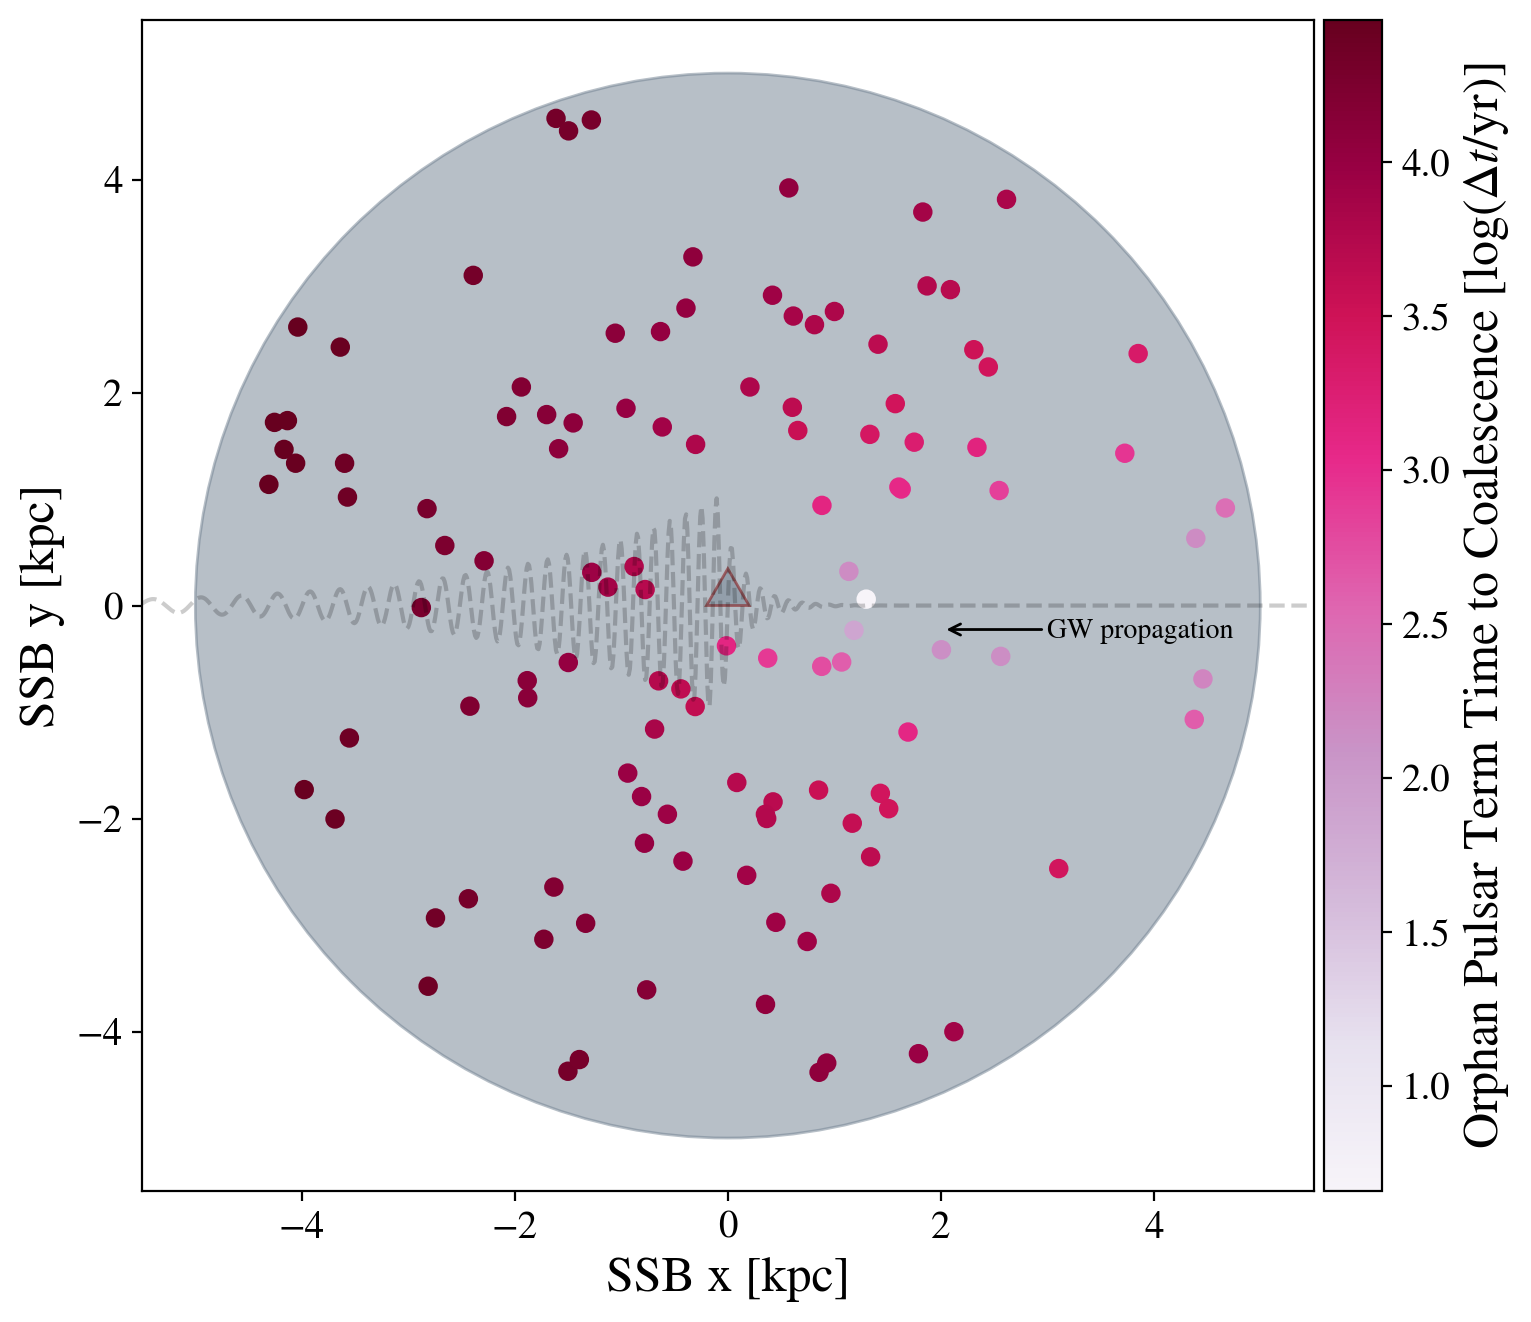

In [95]:
## random phis
## random-ish distances and phis
rng = np.random.default_rng(42)
phis = st.uniform.rvs(0,2*np.pi,size=116,random_state=rng)

plot_extent = (extent + 0.1*extent).value
plt.figure(figsize=(8,8))
plt.plot(plot_waveform_xs,plot_waveform_ys,color='k',alpha=0.2,ls='--')
plt.gca().annotate("", xytext=(3,-.225), xy=(2,-.225),
            arrowprops=dict(arrowstyle="->"))
plt.text(3,-.3,"GW propagation")
plt.gca().add_patch(patches.Circle((0,0),extent.value,color='slategrey',alpha=0.5))
plt.gca().add_patch(patches.Polygon(np.array([[0,0.2*np.sqrt(3)],[0.2,0],[-0.2,0]]),
                                    edgecolor='maroon',facecolor='slategrey',alpha=0.5))
plt.scatter((skycoords.rho*np.cos(phis)).value,
            (skycoords.rho*np.sin(phis)).value,
            c=np.log10((skycoords.rho/const.c).to(u.yr).value*(1-np.cos(phis))),
            cmap='PuRd')#,vmin=0,vmax=250000)
plt.xlim(-plot_extent,plot_extent)
plt.ylim(-plot_extent,plot_extent)
plt.xlabel("SSB x [kpc]",fontsize=18)
plt.ylabel("SSB y [kpc]",fontsize=18)
plt.gca().set_aspect('equal')
# plt.title('Echo Delay Map',fontsize=22)
divider = make_axes_locatable(plt.gca())
cax = divider.append_axes("right", size="5%", pad=0.05)
cb = plt.colorbar(cax=cax)
cb.set_label(label='Orphan Pulsar Term Time to Coalescence [log($\\Delta t$/yr)]',fontsize=18)
utils.savefig('time_delay_diagram_uniform',saveto='./figures/paper_figures/')
# plt.savefig("./figures/time_delay_map.png",dpi=300)
plt.show()

v3 almost fully filled

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


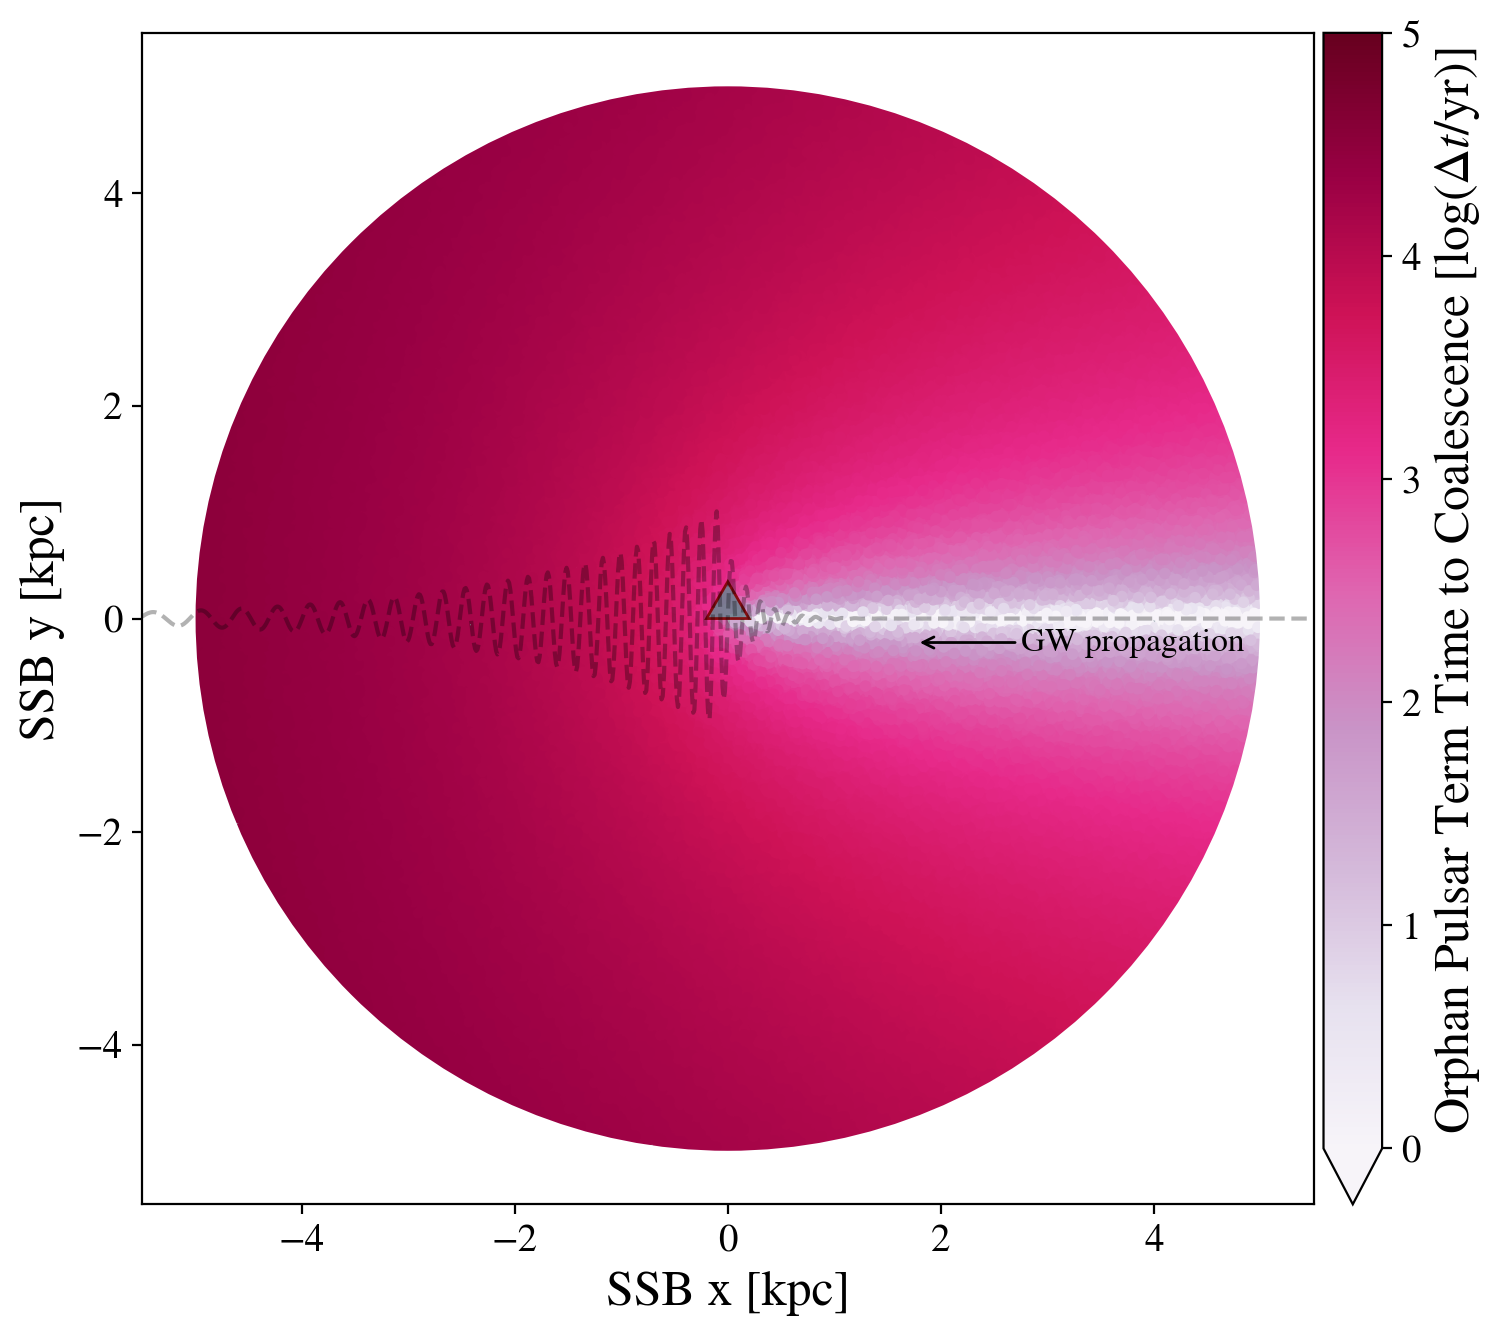

In [170]:
## random phis
## random-ish distances and phis
# rng = np.random.default_rng(42)
# phis = st.uniform.rvs(0,2*np.pi,size=116,random_state=rng)

N_pulsar = 110000
rng = np.random.default_rng(150914)
phis = st.uniform.rvs(0,2*np.pi,size=N_pulsar,random_state=rng)
rs = st.beta.rvs(2,1,scale=extent,size=N_pulsar) ## this is a p(r) ~ r**2 dist

plot_extent = (extent + 0.1*extent).value
plt.figure(figsize=(8,8))
plt.plot(plot_waveform_xs,plot_waveform_ys,color='k',alpha=0.3,ls='--')
plt.gca().annotate("", xytext=(2.75,-.225), xy=(1.75,-.225),
            arrowprops=dict(arrowstyle="->"))
plt.text(2.75,-.3,"GW propagation",fontsize=12)
plt.gca().add_patch(patches.Circle((0,0),extent.value,color='slategrey',alpha=0.5,zorder=-7))
plt.scatter((rs*np.cos(phis)),
            (rs*np.sin(phis)),
            c=np.log10((rs*u.kpc/const.c).to(u.yr).value*(1-np.cos(phis))),
            cmap='PuRd',vmin=0,vmax=5,s=10,zorder=-6)
plt.gca().add_patch(patches.Polygon(np.array([[0,0.2*np.sqrt(3)],[0.2,0],[-0.2,0]]),
                                    edgecolor='maroon',facecolor='slategrey',alpha=0.9))
plt.gca().add_patch(patches.Circle((0,0),1.01*extent.value,edgecolor='white',facecolor=None,fill=False,lw=4))
plt.xlim(-plot_extent,plot_extent)
plt.ylim(-plot_extent,plot_extent)
plt.xlabel("SSB x [kpc]",fontsize=18)
plt.ylabel("SSB y [kpc]",fontsize=18)
plt.gca().set_aspect('equal')
plt.gca().set_rasterization_zorder(-5)
# plt.title('Echo Delay Map',fontsize=22)
divider = make_axes_locatable(plt.gca())
cax = divider.append_axes("right", size="5%", pad=0.05)
cb = plt.colorbar(cax=cax,extend='min')
cb.set_label(label='Orphan Pulsar Term Time to Coalescence [log($\\Delta t$/yr)]',fontsize=18)

utils.savefig('time_delay_diagram_filled',saveto='./figures/paper_figures/')
# plt.savefig("./figures/time_delay_map.png",dpi=300)

plt.show()

## Orphaned Array Response as a Function of GW Origin

In [24]:
## example binary
binary = wt.Binary(5e8,5e8,z=0.5)

In [25]:
snr2_sky, fs_sky, amps_sky = dr3like.calc_allsky_snr(binary)

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3072/3072 [04:45<00:00, 10.74it/s]


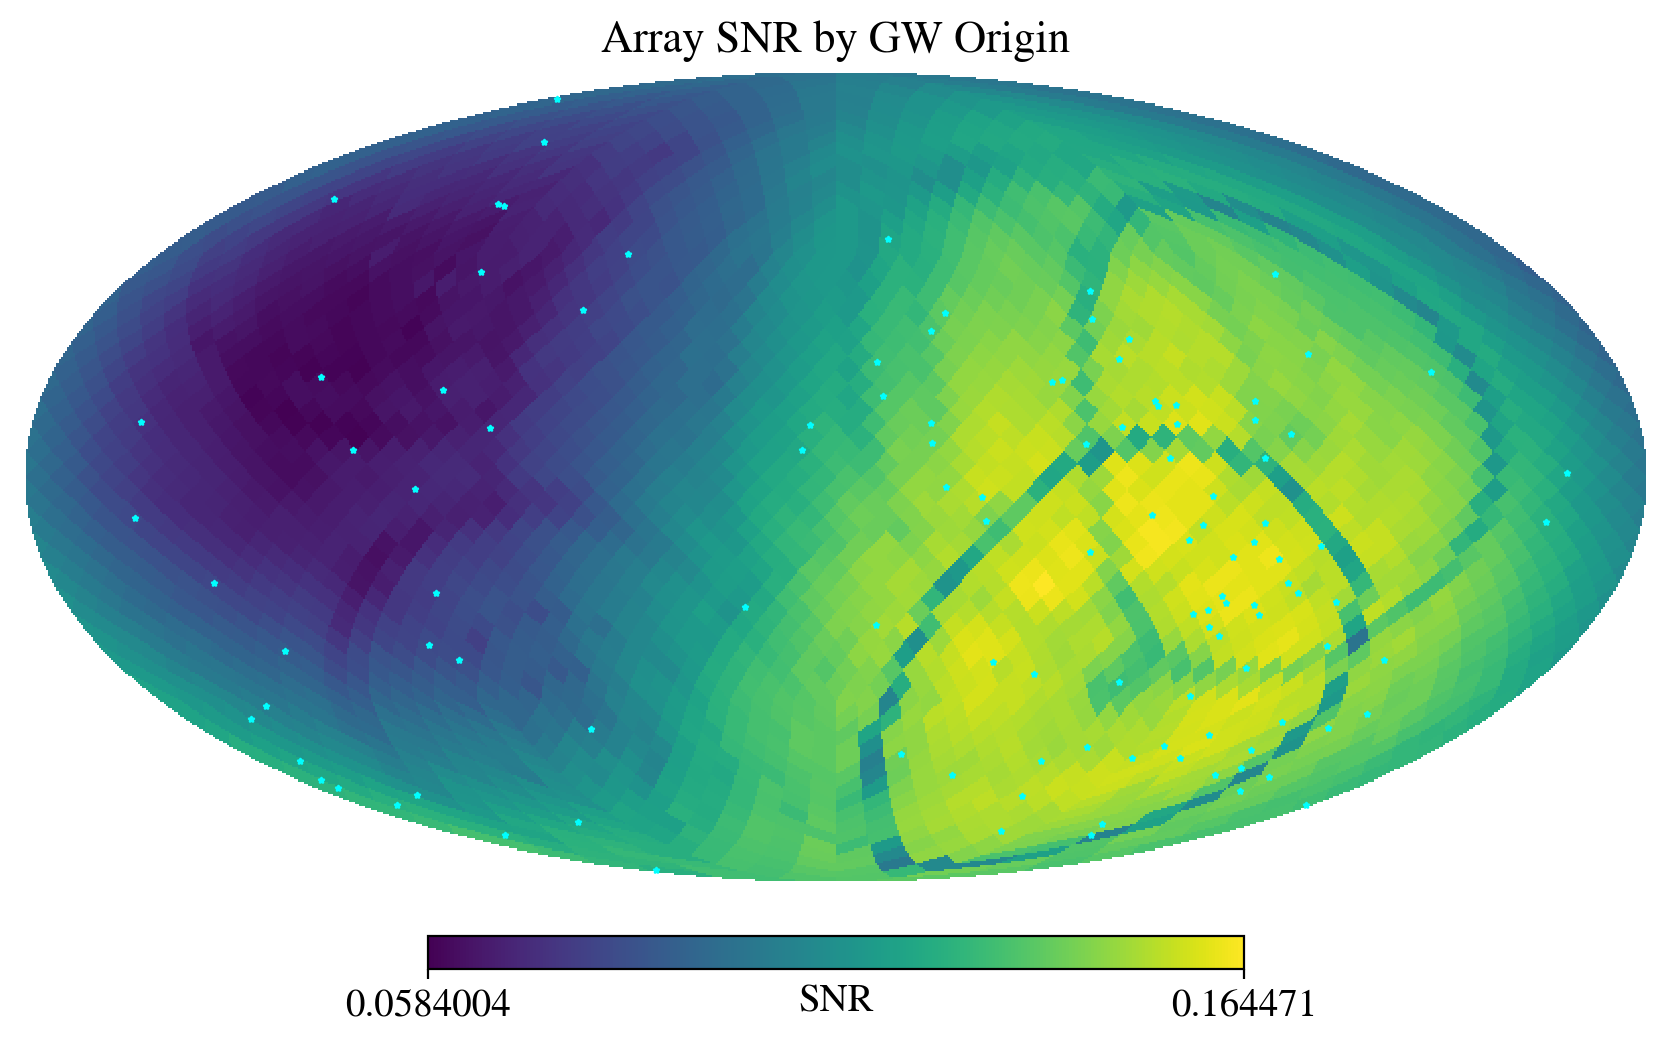

In [38]:
fig = dr3like.plot_snr_skymap(snr2_sky)

The circular "nulls" in the directional sensitivity correspond to the orphand pulsar term frequency in the most sensitive pulsars falling on 1/yr or its harmonics.

In [208]:
np.mean(np.sqrt(dr3like.get_summed_rho2(snr2_sky)))

0.1140411275883756

In [178]:
## try a lower resolution skymap -- same ave?
dr3like_lowres = obs.OrphanArray(nside=8)

Loading Enterprise pulsars...
PSR J2322-2650 complete   
Timespan: 22.2 yrs

Computing correlations...
PSR J2322-2650 complete   
Creating hasasia spectra...
PSR J2322-2650 complete   

In [179]:

snr2_sky_lr, fs_sky_lr, amps_sky_lr = dr3like_lowres.calc_allsky_snr(binary)

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 768/768 [01:09<00:00, 11.00it/s]


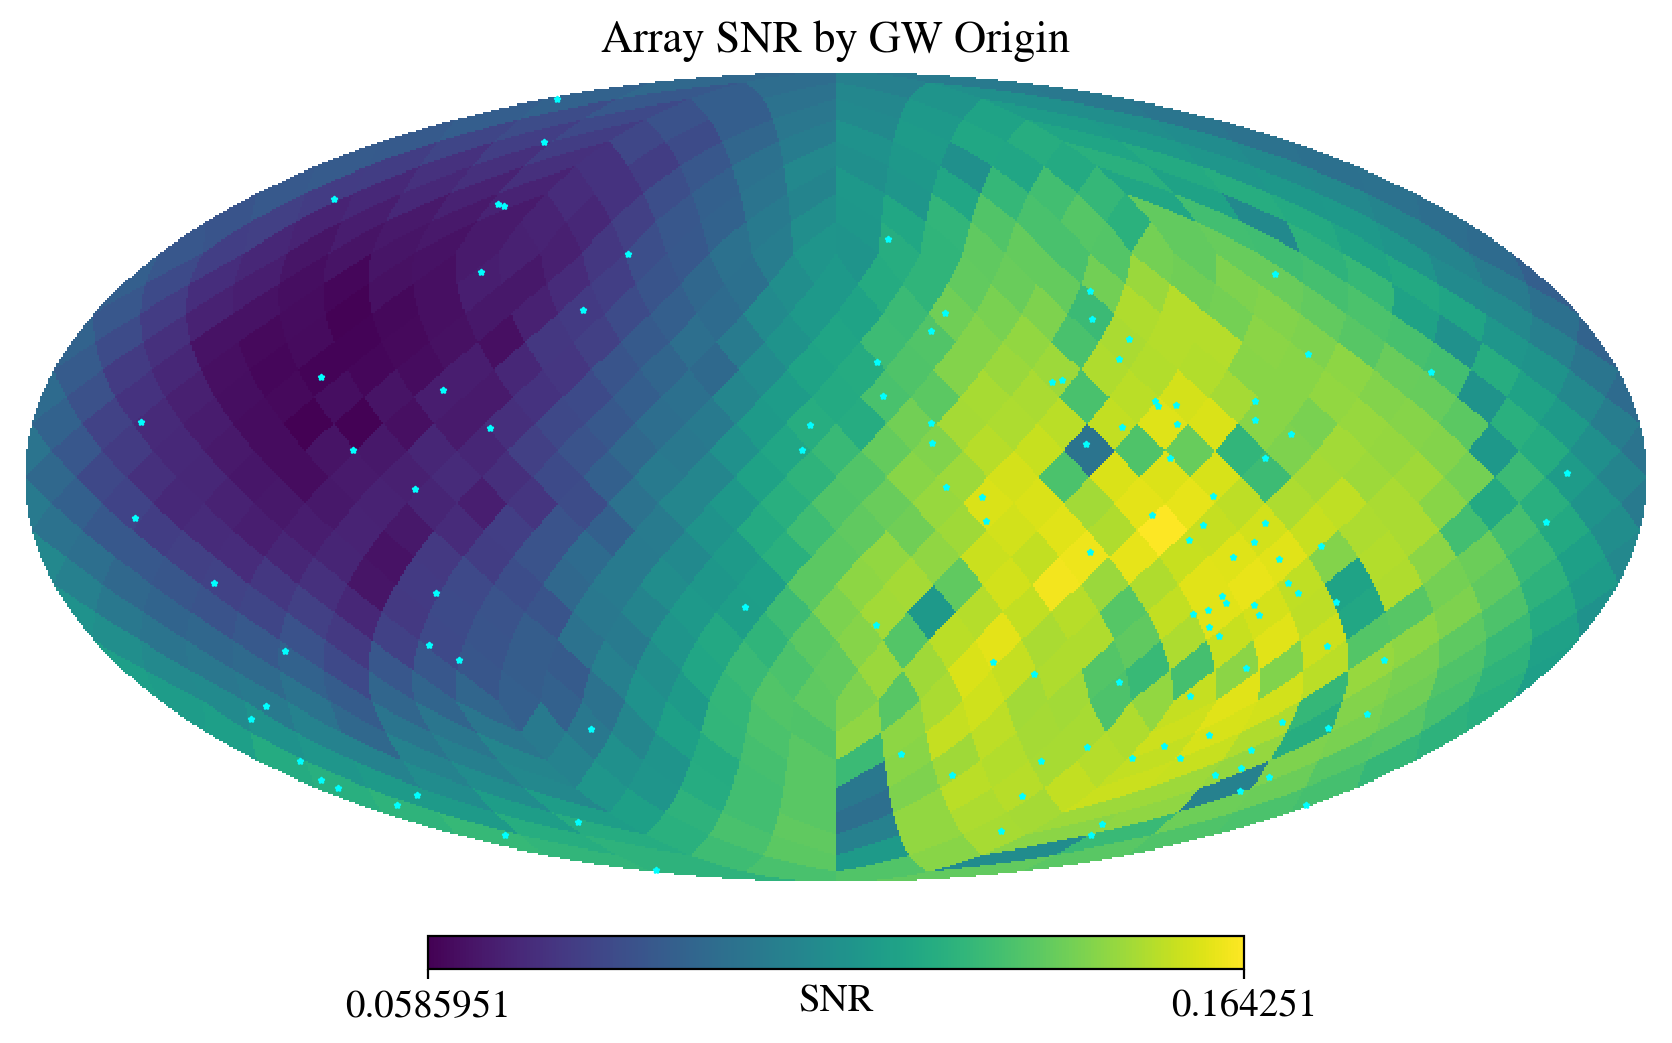

In [180]:
fig = dr3like_lowres.plot_snr_skymap(snr2_sky_lr)

In [207]:
np.mean(np.sqrt(dr3like_lowres.get_summed_rho2(snr2_sky_lr)))

0.11394677337269328

Can we go even lower?

In [182]:
## try a lower resolution skymap -- same ave?
dr3like_2xlowres = obs.OrphanArray(nside=4)

Loading Enterprise pulsars...
PSR J2322-2650 complete   
Timespan: 22.2 yrs

Computing correlations...
PSR J2322-2650 complete   
Creating hasasia spectra...
PSR J2322-2650 complete   

In [183]:

snr2_sky_2lr, fs_sky_2lr, amps_sky_2lr = dr3like_2xlowres.calc_allsky_snr(binary)

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 192/192 [00:17<00:00, 11.19it/s]


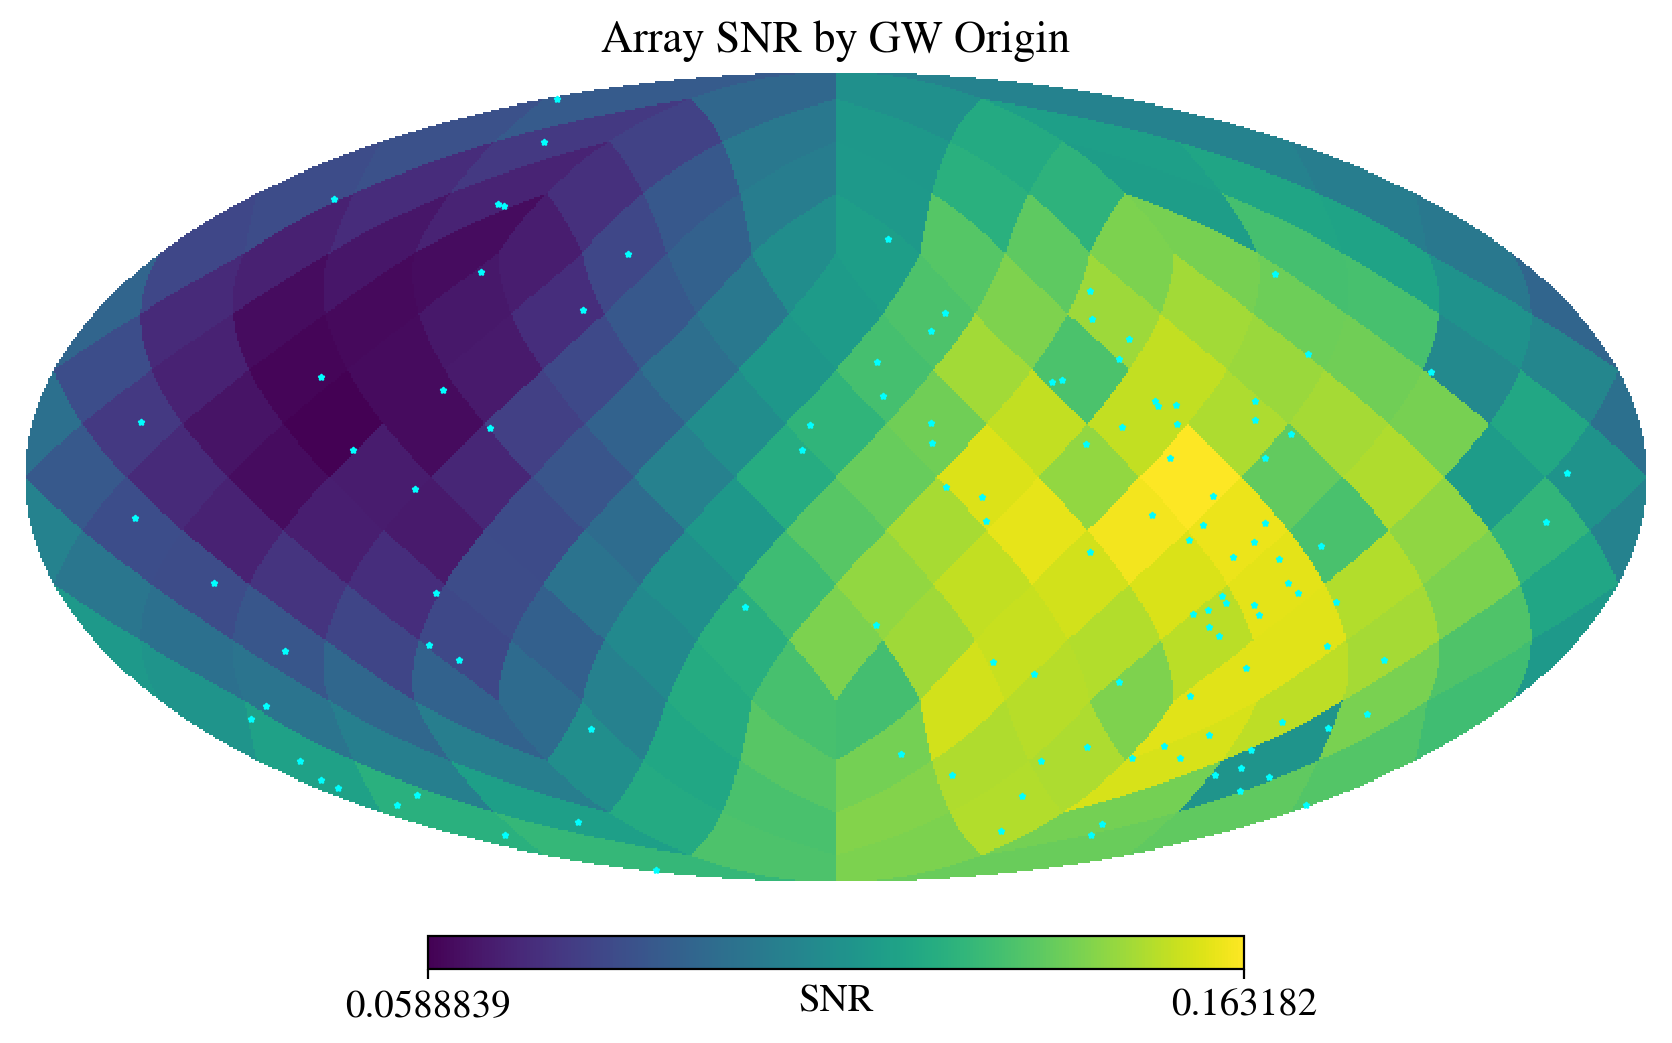

In [184]:
fig = dr3like_2xlowres.plot_snr_skymap(snr2_sky_2lr)

In [206]:
np.mean(np.sqrt(dr3like_2xlowres.get_summed_rho2(snr2_sky_2lr)))

0.1144288510077011

Repeat the trial with another system:

In [186]:
## example binary
binary = wt.Binary(5e9,5e9,z=0.5)

In [187]:
snr2_sky_t2, fs_sky_t2, amps_sky_t2 = dr3like.calc_allsky_snr(binary)

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3072/3072 [04:36<00:00, 11.11it/s]


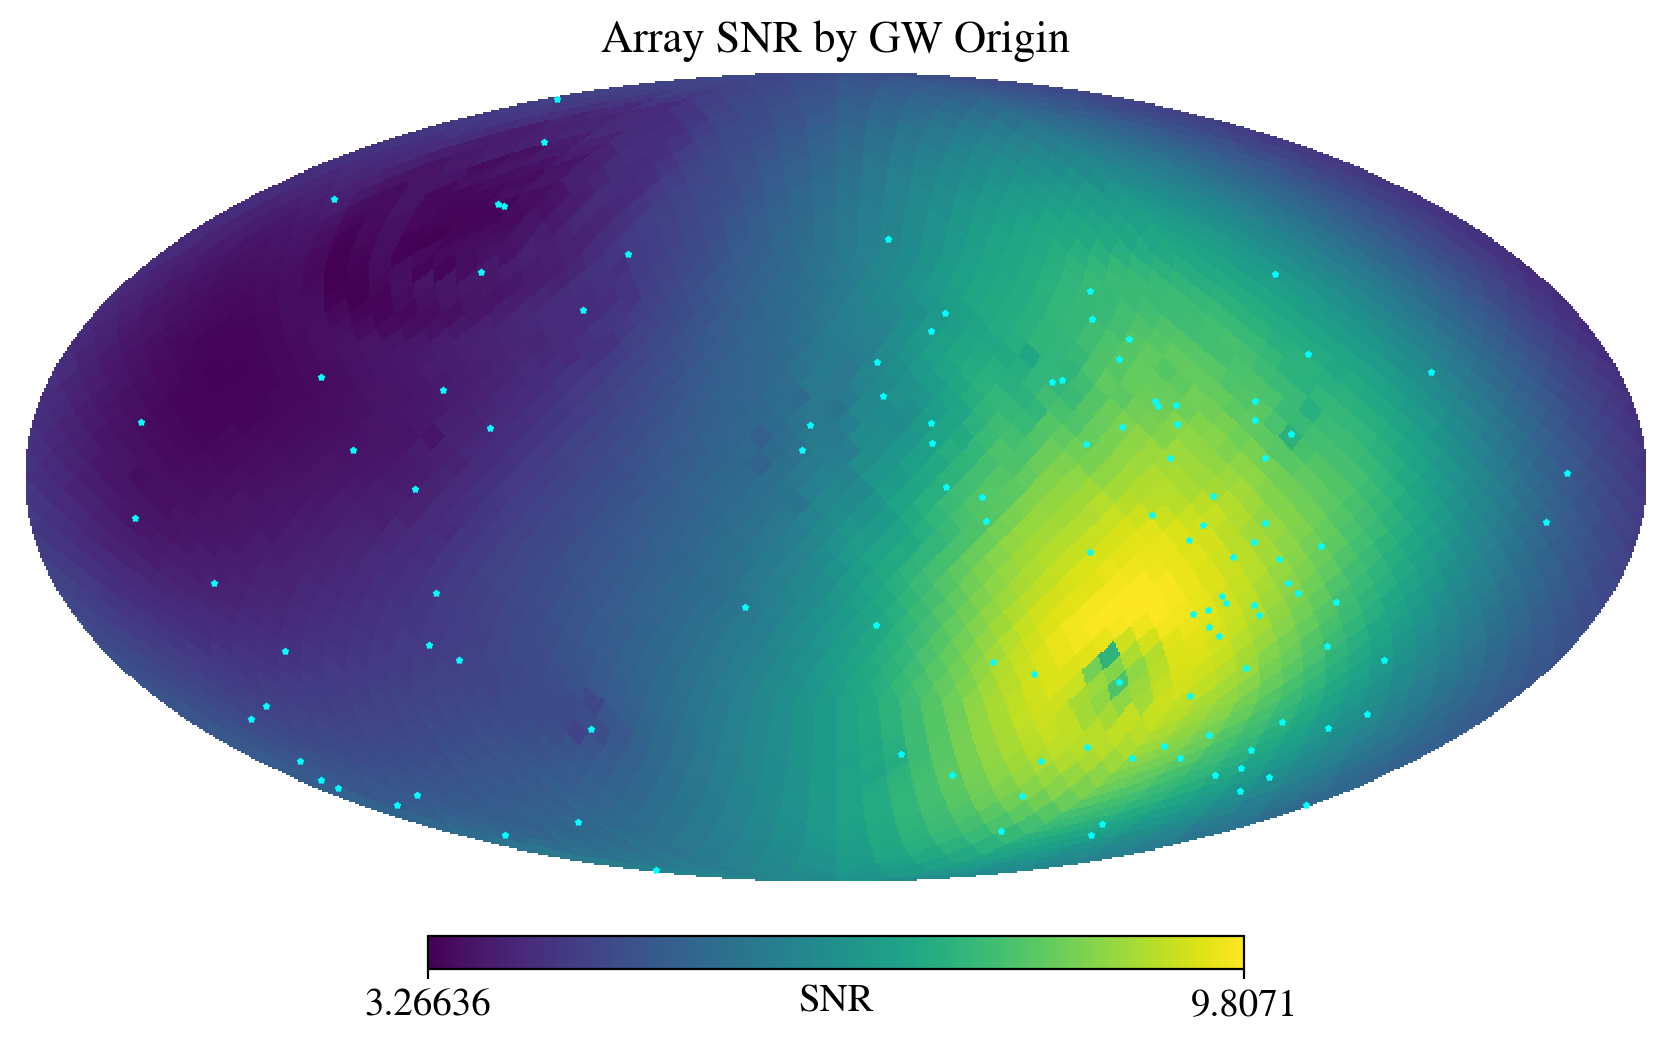

In [188]:
fig = dr3like.plot_snr_skymap(snr2_sky_t2)

In [205]:
np.mean(np.sqrt(dr3like.get_summed_rho2(snr2_sky_t2)))

5.821145687115318

In [190]:

snr2_sky_lr_t2, fs_sky_lr_t2, amps_sky_lr_t2 = dr3like_lowres.calc_allsky_snr(binary)

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 768/768 [01:09<00:00, 11.05it/s]


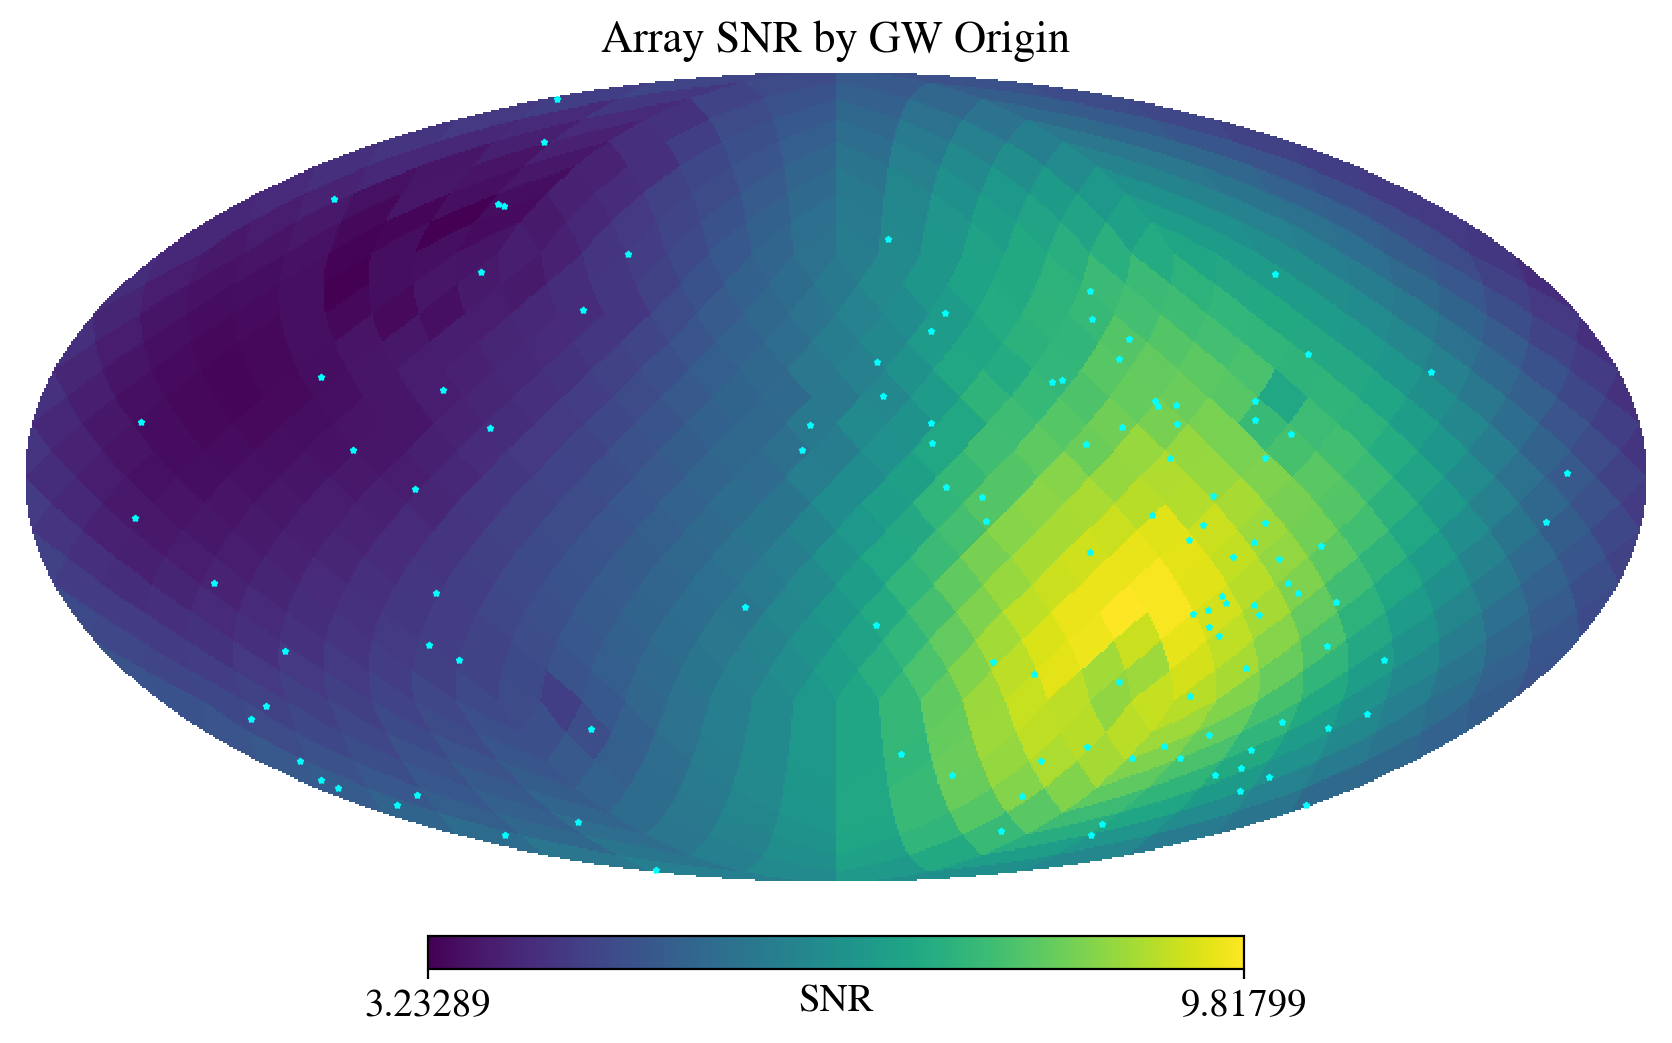

In [191]:
fig = dr3like_lowres.plot_snr_skymap(snr2_sky_lr_t2)

In [204]:
np.mean(np.sqrt(dr3like_lowres.get_summed_rho2(snr2_sky_lr_t2)))

5.821021201038473

Can we go even lower?

In [193]:

snr2_sky_2lr_t2, fs_sky_2lr_t2, amps_sky_2lr_t2 = dr3like_2xlowres.calc_allsky_snr(binary)

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 192/192 [00:17<00:00, 11.20it/s]


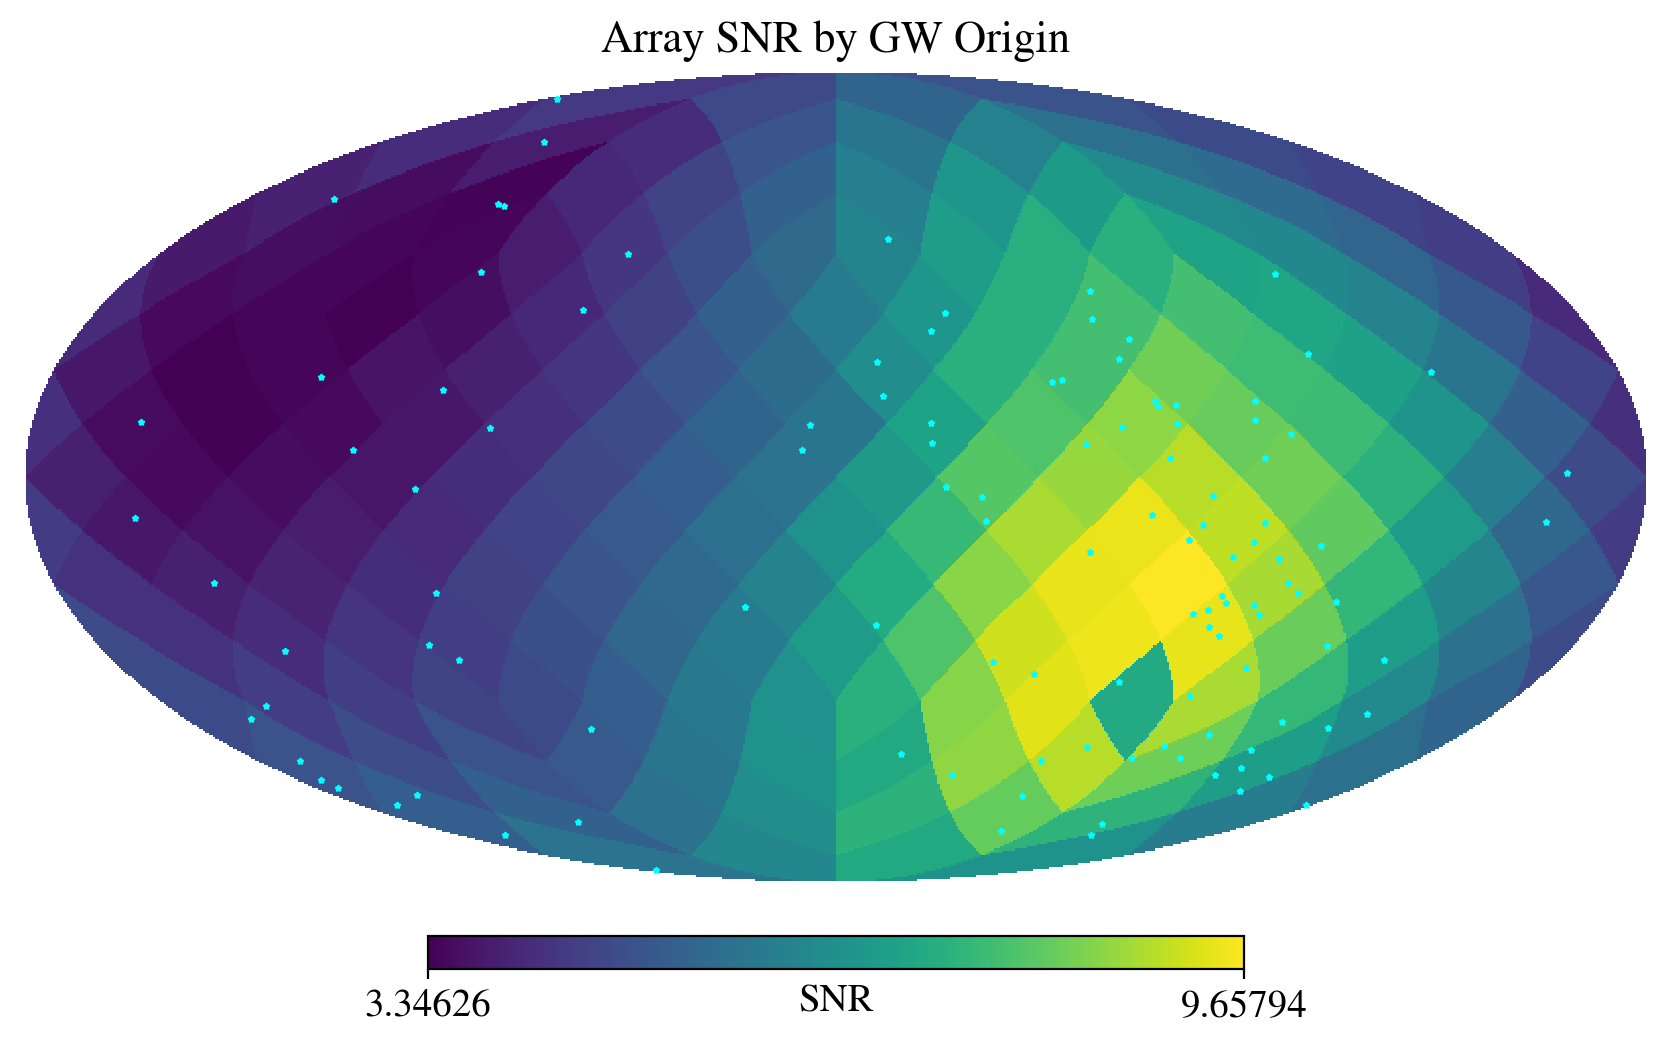

In [194]:
fig = dr3like_2xlowres.plot_snr_skymap(snr2_sky_2lr_t2)

In [203]:
np.mean(np.sqrt(dr3like_2xlowres.get_summed_rho2(snr2_sky_2lr_t2)))

5.816903140661847

Okay, I'm happy with that. We can trust the SNR results to 2 digits, and while we lose some of the fine resolution of the response, this still alows us to perform sky-averaged SNR to the accuracy we need without egregious computational requirements.

## SNR Calculations Across M-z grid

Here, we compute the sky-averaged SNR at every point on the logM-logz grid provided for the rates for $\log_{10}(M/M_{\odot}) > 7.0$.

In [196]:
## check grid size 
logz_bins.shape, logM_bins.shape

((78,), (176,))

In [197]:
## cut to M>=10^7 Msun
logM_bins_rdx = logM_bins[logM_bins > 7.0]
len(logM_bins_rdx)

72

In [221]:
78*72*16/3600

24.96

In [220]:
## get multiband SNRs for a random binary
baseHP = ahp.HEALPix(4,frame='barycentricmeanecliptic')
sky_loc = baseHP.healpix_to_skycoord(850) ## random sky loc, will do average over sky later
## assuming equal mass ratios for now
Nm = 1
Nz = 1
T_merge = 1*obs.YEAR
Mtots = np.logspace(7,11,Nm)
zs = np.linspace(0.01,8,Nz)
snrs = {name:np.empty((Nm,Nz)) for name in [lisa.name,muAres.name,kepler.survey,roman.survey,'orphans']}
for i in tqdm(range(len(Mtots))):
    for j in range(len(zs)):
        # m1 = m2 = Mtots[i]/2
        m1 = 0.5*Mtots[i].copy()
        m2 = 0.5*Mtots[i].copy()
        z = zs[j]
        for obs_i in [lisa,muAres,kepler,roman]:
            binary_i = wt.Binary(m1,m2,z=z)
            if obs_i.name == 'astrometry':
                name_i = obs_i.survey
            else:
                name_i = obs_i.name
            snrs[name_i][i,j] = binary_i.run_full_SNR_calc(obs_i,T_merge)
        snr2_sky_ij, fs_sky_ij, amps_sky_ij = dr3like_2xlowres.calc_allsky_snr(binary_i,prog=False)
        snrs['orphans'][i,j] = np.mean(np.sqrt(dr3like_2xlowres.get_summed_rho2(snr2_sky_ij)))

  0%|                                                                                                                                                        | 0/1 [00:00<?, ?it/s]

0.00034117698669433594
0.0001678466796875
0.00011706352233886719
0.00012540817260742188


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:16<00:00, 16.94s/it]

16.928082942962646
0.0066776275634765625


In [223]:
merger_snr_min = 50

SNR parameter-space "maps":

In [224]:
any_cond = np.any([snrs[name]>merger_snr_min for name in [lisa.name,muAres.name,kepler.survey,roman.survey]],axis=0)

In [225]:
any_arr = np.ma.array(np.log10(snrs['orphans']),mask=np.invert(any_cond),fill_value=np.nan)
single_arrs = []
names = [lisa.name,muAres.name,kepler.survey,roman.survey]
for name in names:
    cond_i = snrs[name]>merger_snr_min
    single_arrs.append(np.ma.array(np.log10(snrs['orphans']),mask=np.invert(cond_i),fill_value=np.nan))

In [217]:
# Mgrid, zgrid = np.meshgrid(Mtots,zs)
# plt.figure()
# plt.xscale('log')
# plt.contourf(Mgrid.T,zgrid.T,any_arr,cmap='cool',vmin=-1,levels=[-1,0,1,2,3,4,5],extend='both')
# legend_elements = [Patch(facecolor='white', edgecolor='k',label='Merger SNR <{}'.format(merger_snr_min))]
# plt.legend(handles=legend_elements, loc='upper right')
# plt.xlabel('Total Mass [Msun]')
# plt.ylabel('Redshift')
# # plt.legend(bbox_to_anchor=(1,1))
# plt.colorbar(label='log10 Echo SNR')
# plt.title("Any Combination")
# plt.savefig('/home/awc/Documents/NANOGrav/multiband_echoes/multiband_smbhbs/figures/parameter_space_snrs/Mz_SNR_Any.png',dpi=200)
# plt.show()

In [226]:
def set_style():
    plt.style.use('default')
    default_cycler=plt.cycler(color=['mediumorchid','teal','navy','firebrick','goldenrod','slategrey'])
    plt.rc('axes', prop_cycle=default_cycler)
    
    ## TODO -- add some font size/style, etc. here
    plt.rcParams['font.family'] = 'STIXGeneral'  # Closely matches Computer Modern
    
    plt.rcParams['mathtext.fontset'] = 'stix'    # Use STIX for math
    plt.rcParams['axes.titlesize'] = 16
    plt.rcParams['axes.labelsize'] = 14
    plt.rcParams['xtick.labelsize'] = 14
    plt.rcParams['ytick.labelsize'] = 14
    
    return

In [227]:
set_style()

In [220]:
# import matplotlib.font_manager; [font for font in matplotlib.font_manager.get_font_names() if 'Noto' not in font]

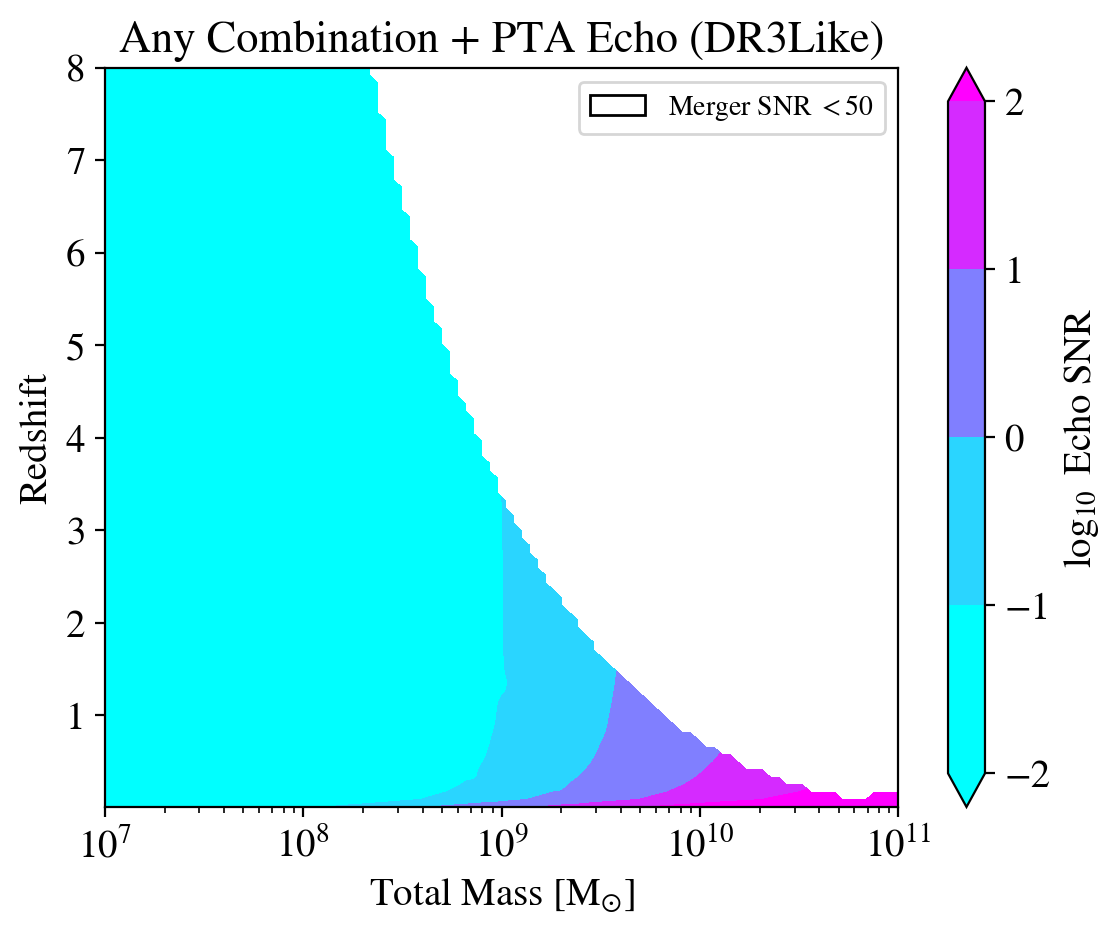

In [228]:
Mgrid, zgrid = np.meshgrid(Mtots,zs)
plt.figure()
plt.xscale('log')
plt.contourf(Mgrid.T,zgrid.T,any_arr,cmap='cool',vmin=-1,levels=[-2,-1,0,1,2],extend='both')
legend_elements = [Patch(facecolor='white', edgecolor='k',label='Merger SNR $<{}$'.format(merger_snr_min))]
plt.legend(handles=legend_elements, loc='upper right')
plt.xlabel(r'Total Mass [$\mathrm{M_{\odot}}$]')
plt.ylabel('Redshift')
# plt.legend(bbox_to_anchor=(1,1))
plt.colorbar(label=r'$\log_{10}$ Echo SNR')
plt.title("Any Combination + PTA Echo (DR3Like)")
plt.savefig('/home/awc/Documents/NANOGrav/multiband_echoes/multiband_smbhbs/figures/parameter_space_snrs/Mz_SNR_Any.png',dpi=200)
plt.show()

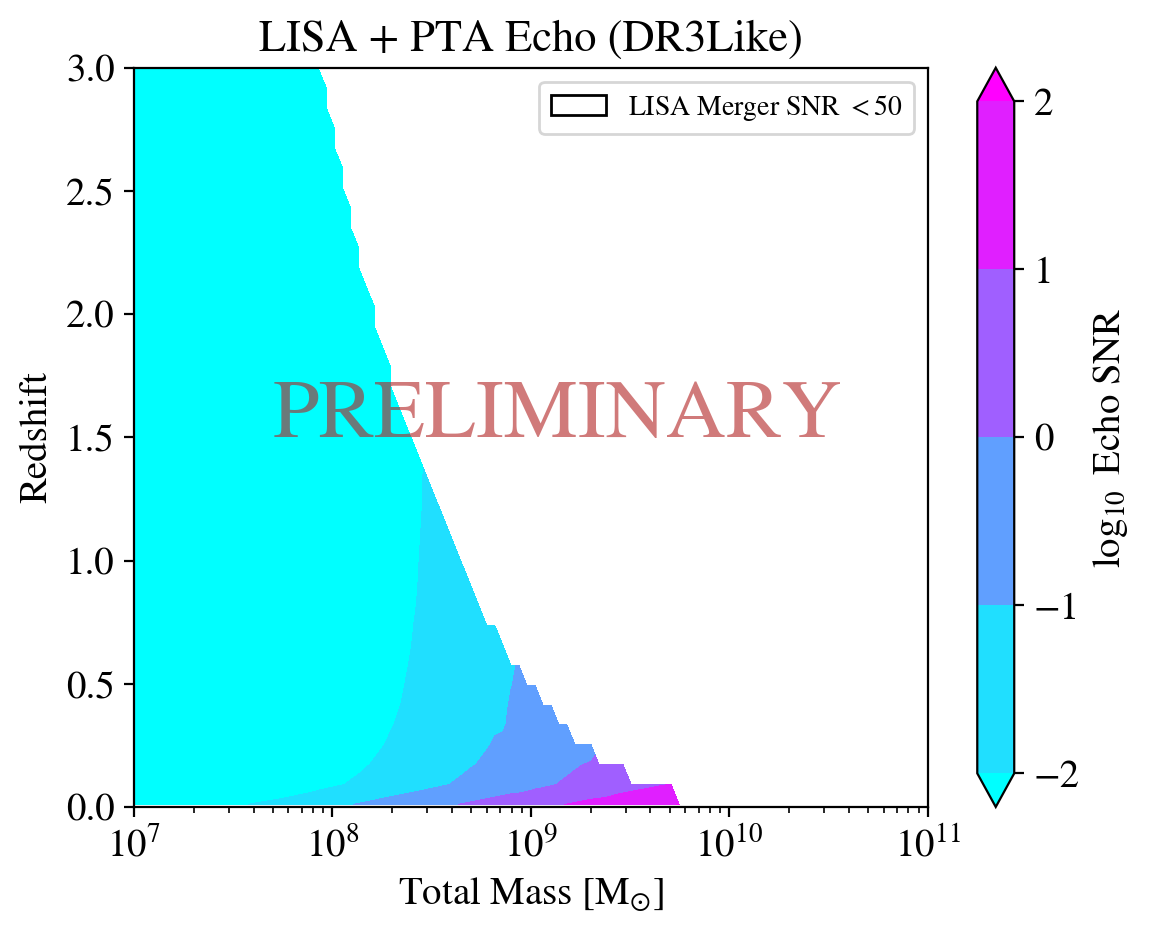

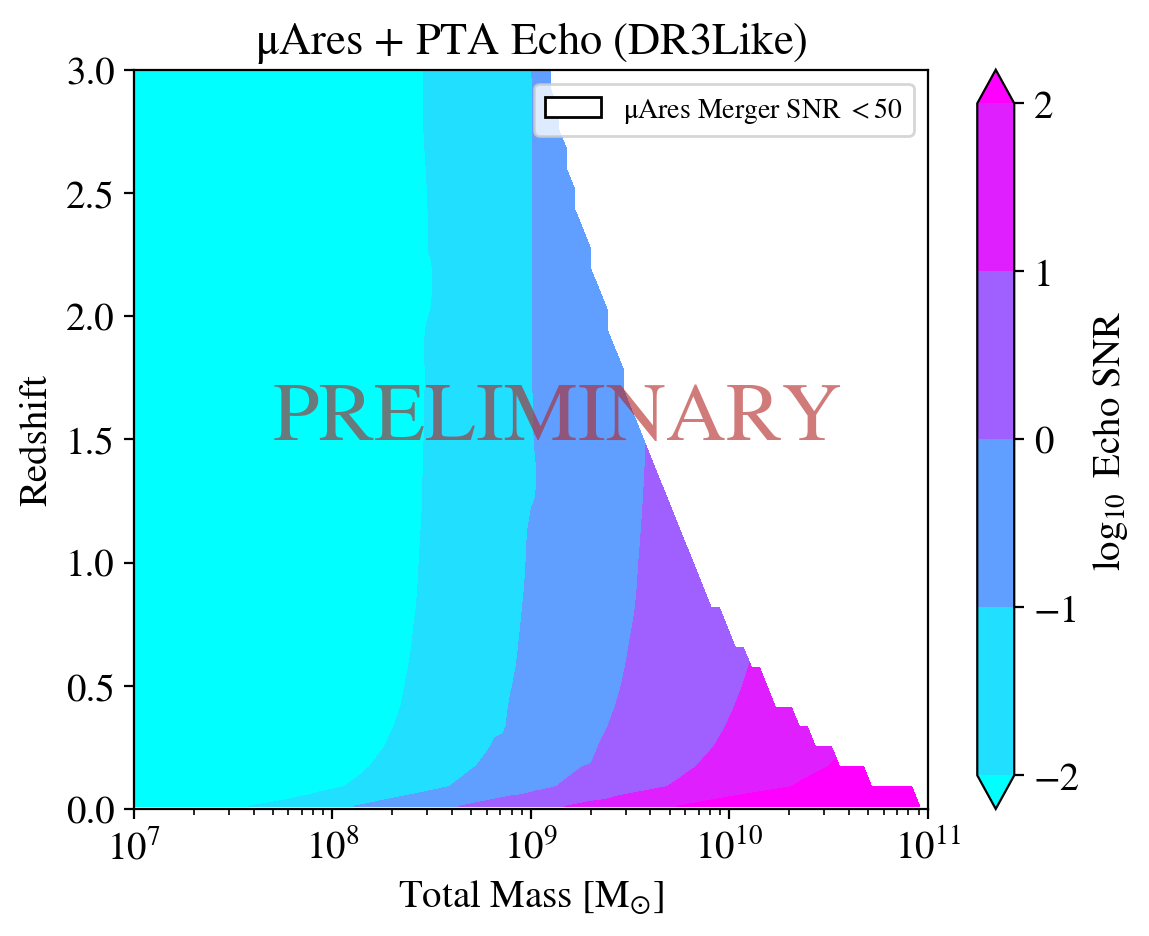

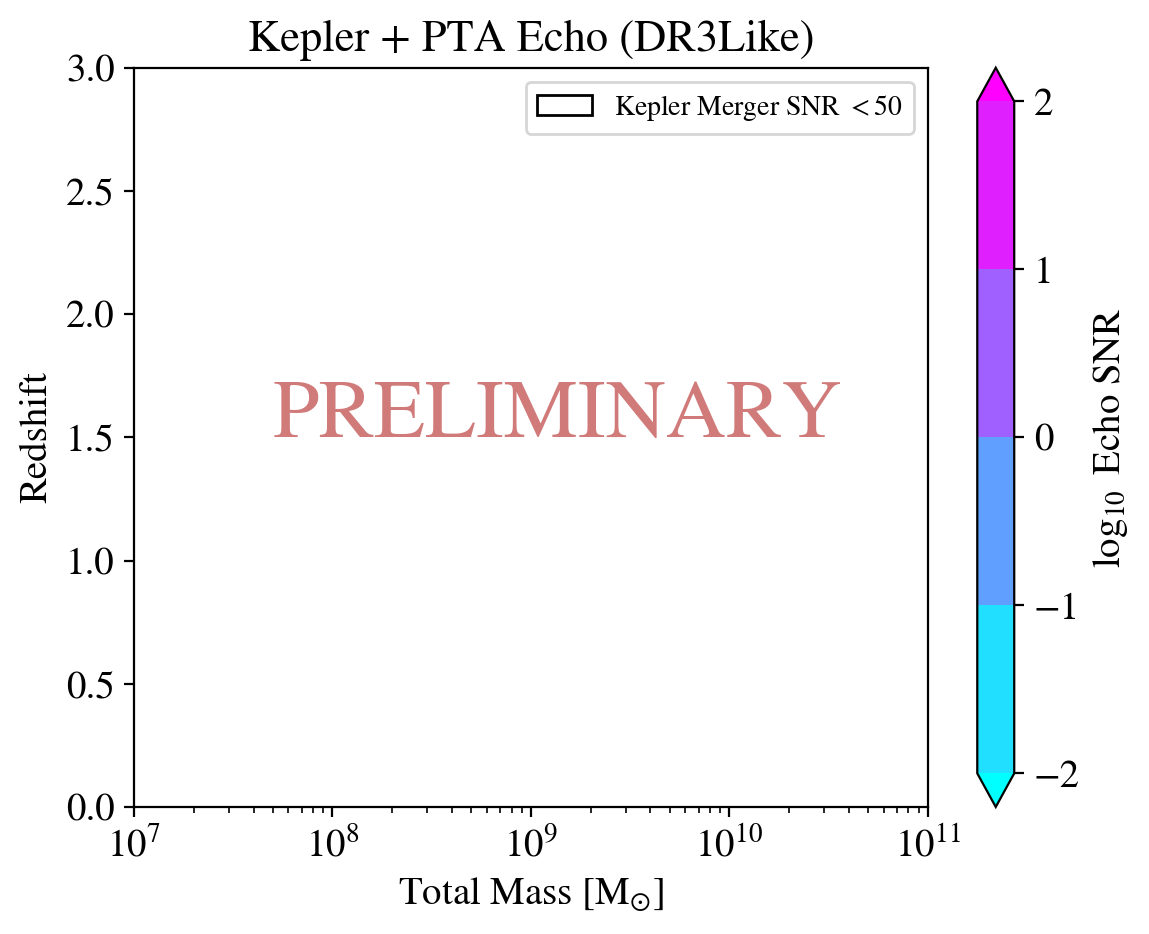

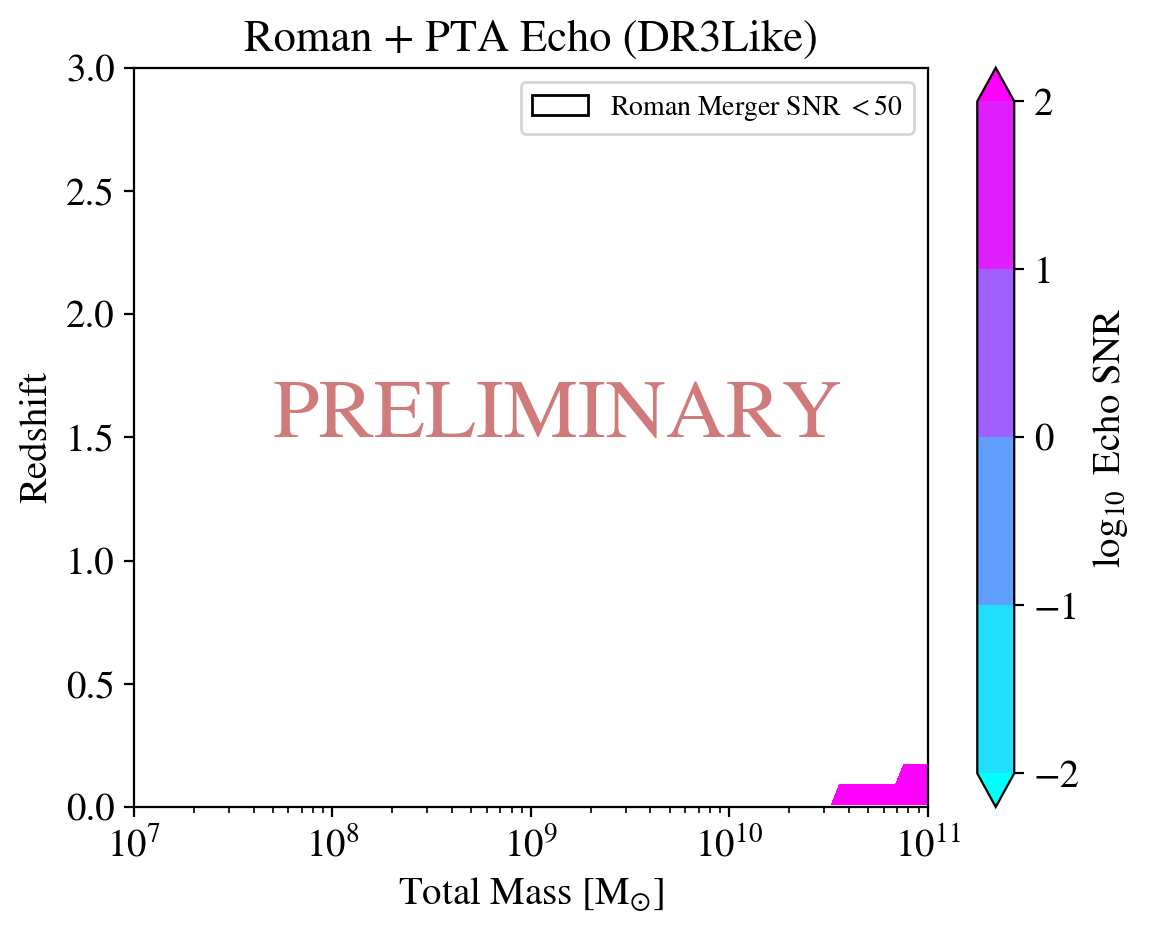

In [229]:
for i in range(len(names)):
    name_i = names[i]
    if names[i]=='muAres':
        name_i = r'$\mathrm{\mu}$Ares'
    plt.figure()
    plt.xscale('log')
    plt.contourf(Mgrid.T,zgrid.T,single_arrs[i],cmap='cool',levels=[-2,-1,0,1,2],extend='both')
    legend_elements = [Patch(facecolor='white', edgecolor='k',label='{} Merger SNR $<{}$'.format(name_i,merger_snr_min))]
    plt.legend(handles=legend_elements, loc='upper right')
    plt.xlabel(r'Total Mass [$\mathrm{M_{\odot}}$]')
    plt.ylabel('Redshift')
    plt.ylim(0,3)
    plt.colorbar(label=r'$\log_{10}$ Echo SNR')
    plt.title("{} + PTA Echo (DR3Like)".format(name_i))
    plt.text(5e7,1.5,"PRELIMINARY",fontsize=30,color='firebrick',alpha=0.6)
    # plt.savefig('/home/awc/Documents/NANOGrav/multiband_echoes/multiband_smbhbs/figures/parameter_space_snrs_lowz_msnr10/Mz_SNR_{}.png'.format(names[i]),
    #             dpi=200)
    plt.show()

/tmp/ipykernel_401314/2420621287.py:5: RuntimeWarning: divide by zero encountered in log10
  plt.contourf(Mgrid.T,zgrid.T,np.log10(snrs[names[i]]),cmap='cool',levels=[-1,0,1,2,3],extend='both')


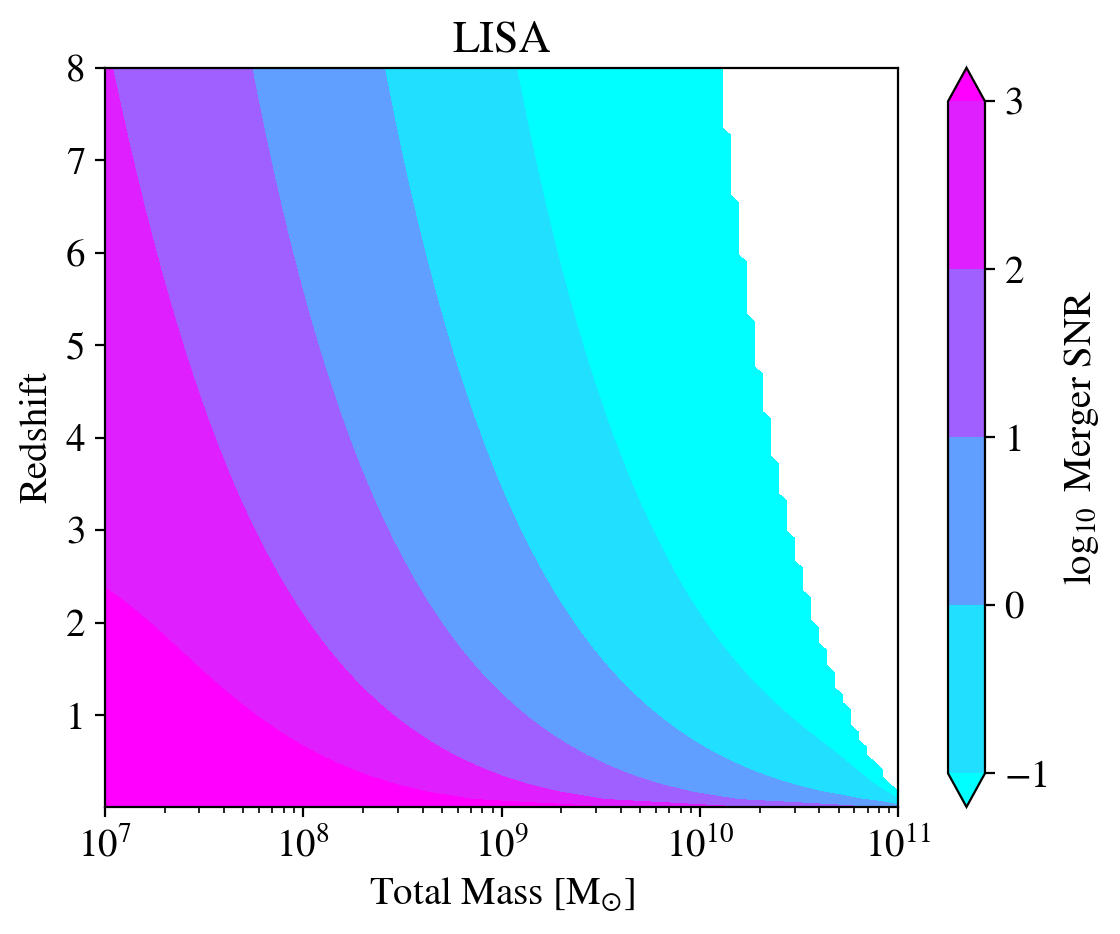

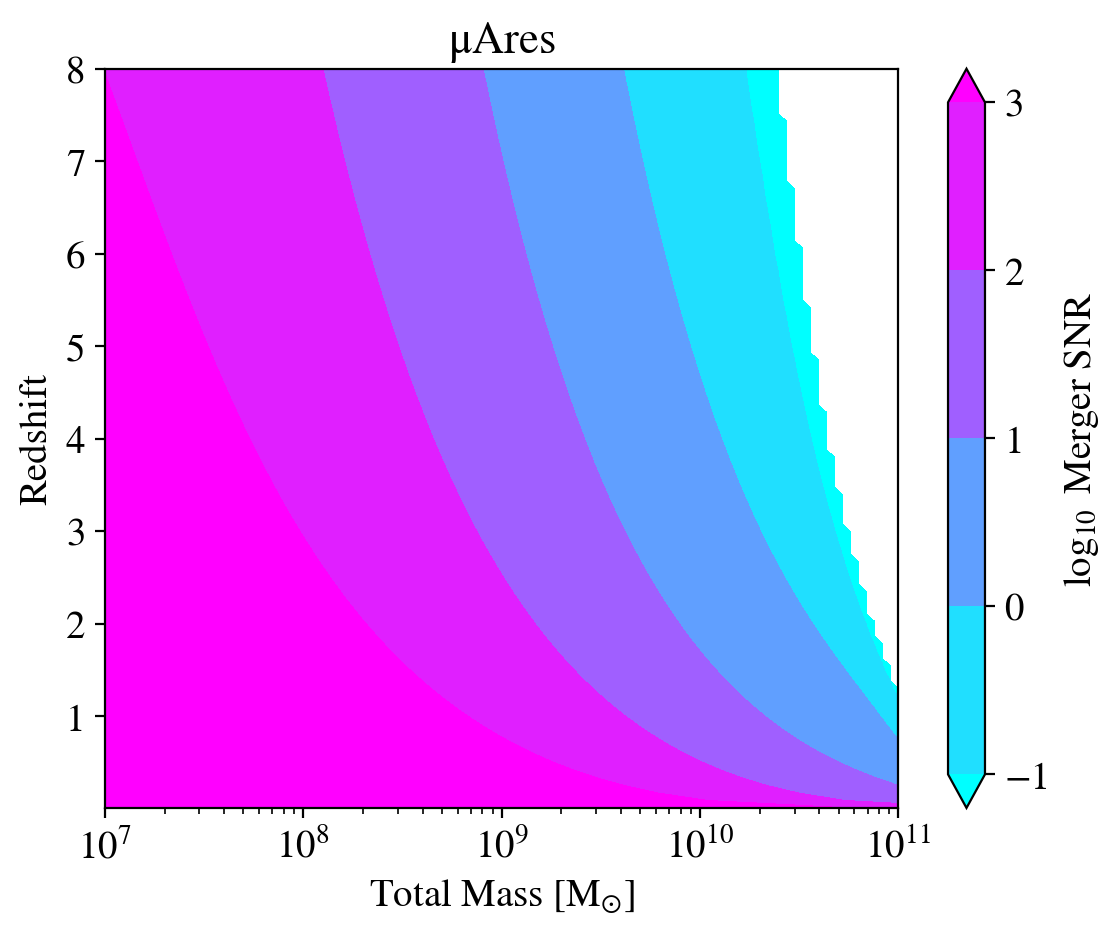

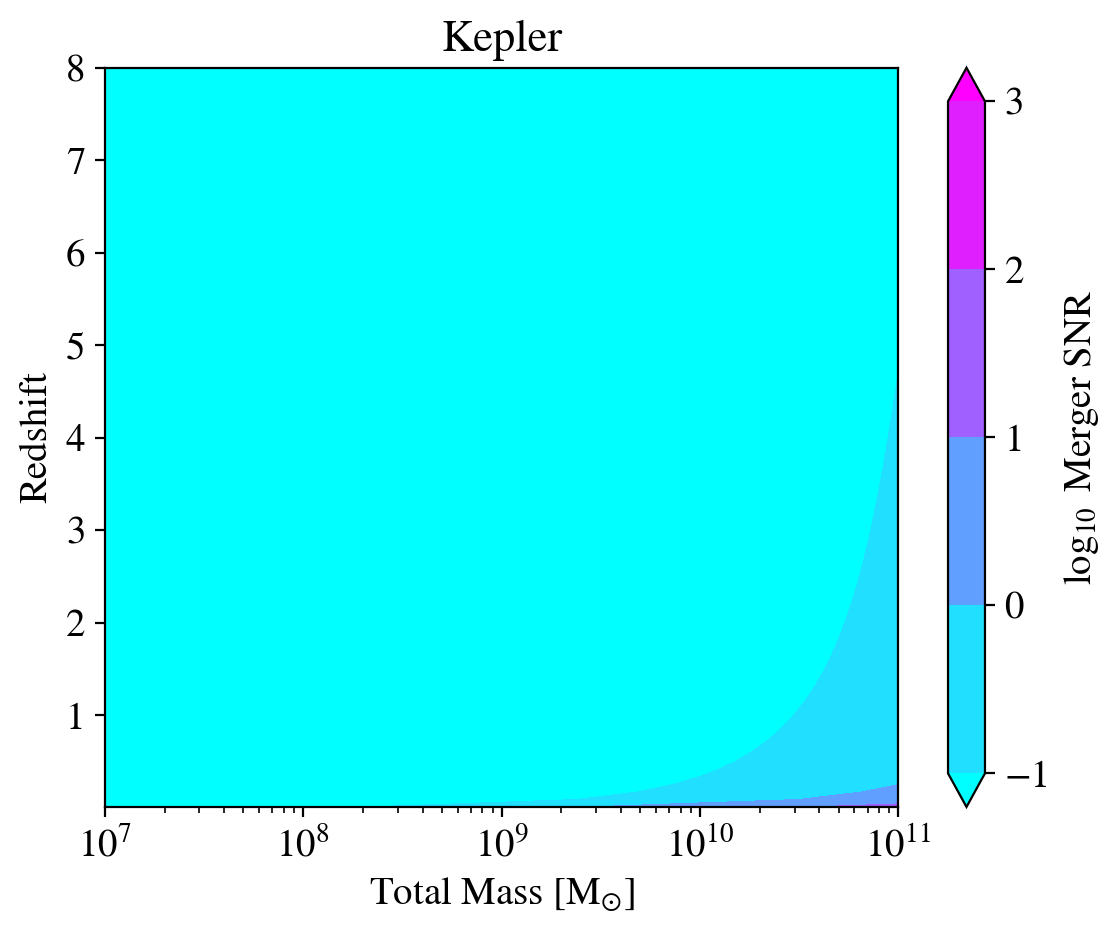

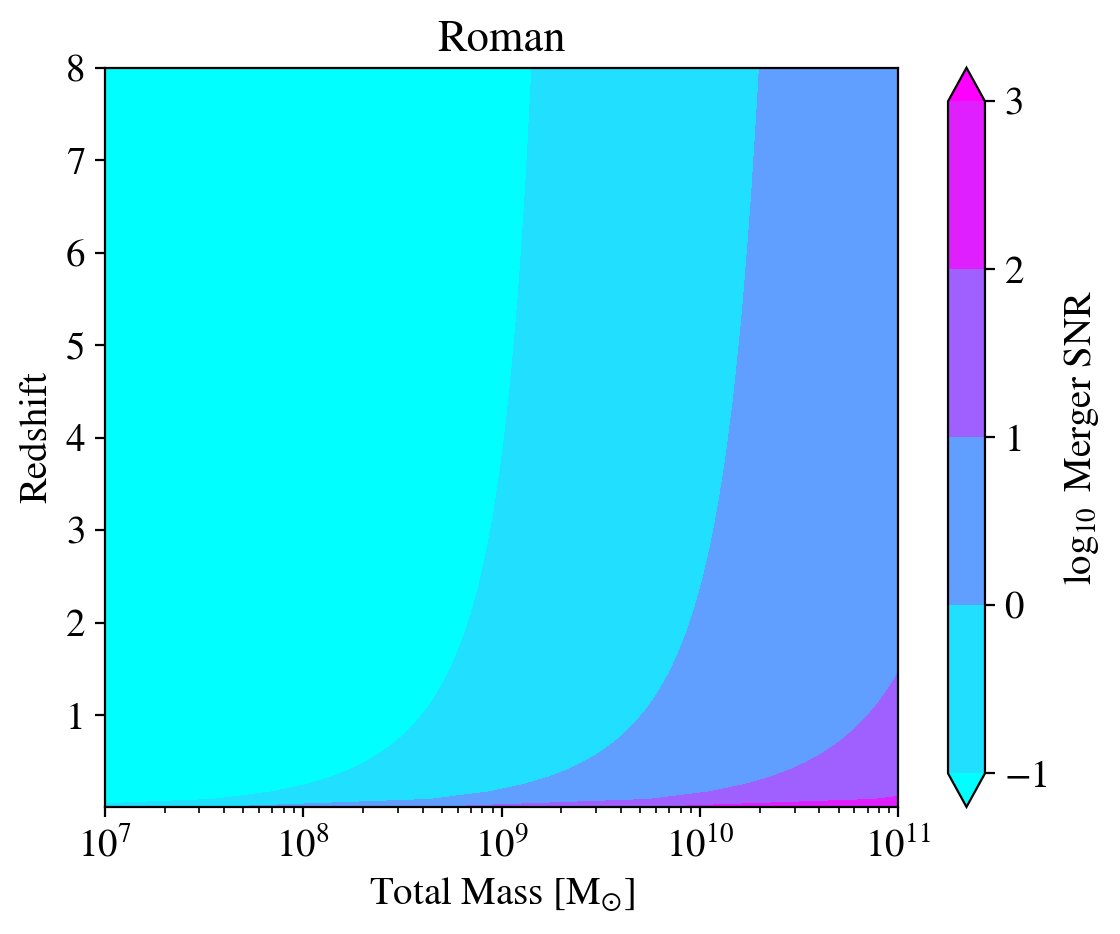

In [193]:
## check merger SNR maps
for i in range(len(names)):
    plt.figure()
    plt.xscale('log')
    plt.contourf(Mgrid.T,zgrid.T,np.log10(snrs[names[i]]),cmap='cool',levels=[-1,0,1,2,3],extend='both')
    plt.xlabel(r'Total Mass [$\mathrm{M_{\odot}}$]')
    plt.ylabel('Redshift')
    plt.colorbar(label=r'$\log_{10}$ Merger SNR')
    name_i = names[i]
    if names[i]=='muAres':
        name_i = r'$\mathrm{\mu}$Ares'
    plt.title("{}".format(name_i))
    plt.savefig('/home/awc/Documents/NANOGrav/multiband_echoes/multiband_smbhbs/figures/parameter_space_snrs/Mz_merger_SNR_{}.png'.format(names[i]),
                dpi=200)
    plt.show()

Yes/no plots

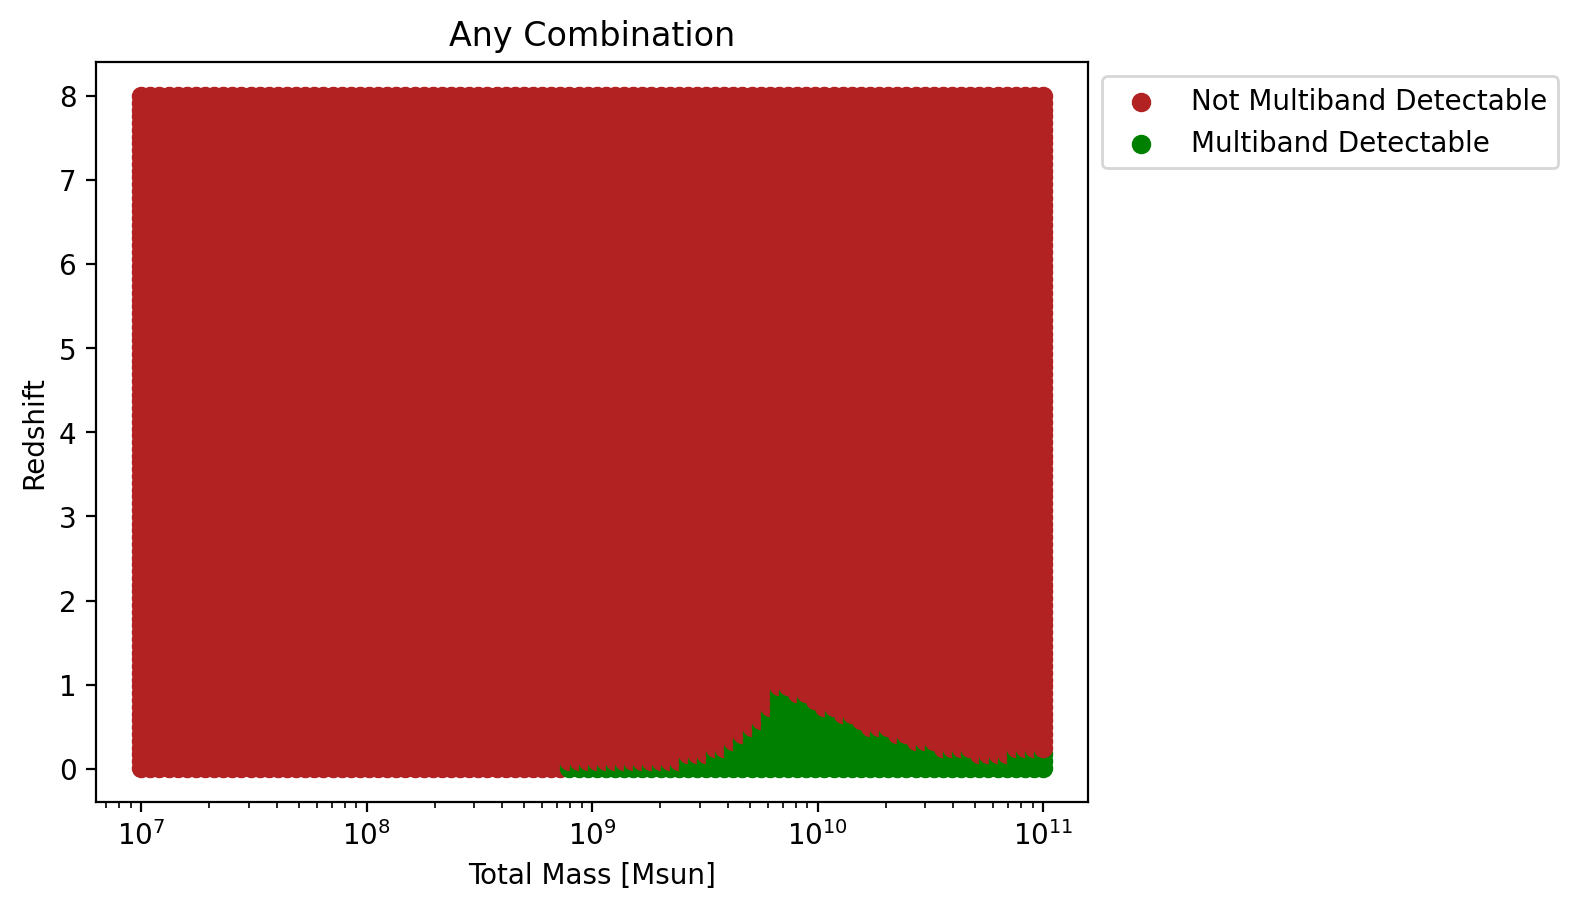

In [121]:
plt.figure()
plt.xscale('log')
rc = 0
gc = 0
for i in range(Nm):
    for j in range(Nz):
        echo_cond = snrs['echo'][i,j] > 3
        merge_cond = np.any([snrs[name][i,j]>merger_snr_min for name in [lisa.name,muAres.name,kepler.survey,roman.survey]])
        if echo_cond*merge_cond:
            if gc == 0:
                lab_i = 'Multiband Detectable'
                gc += 1
            else:
                lab_i = '__nolabel__'                
            col_i = 'green'
        else:
            if rc == 0:
                lab_i = 'Not Multiband Detectable'
                rc += 1
            else:
                lab_i = '__nolabel__'   
            col_i = 'firebrick'
        plt.scatter(Mtots[i],zs[j],color=col_i,label=lab_i)
plt.xlabel('Total Mass [Msun]')
plt.ylabel('Redshift')
plt.legend(bbox_to_anchor=(1,1))
plt.title("Any Combination")
plt.show()

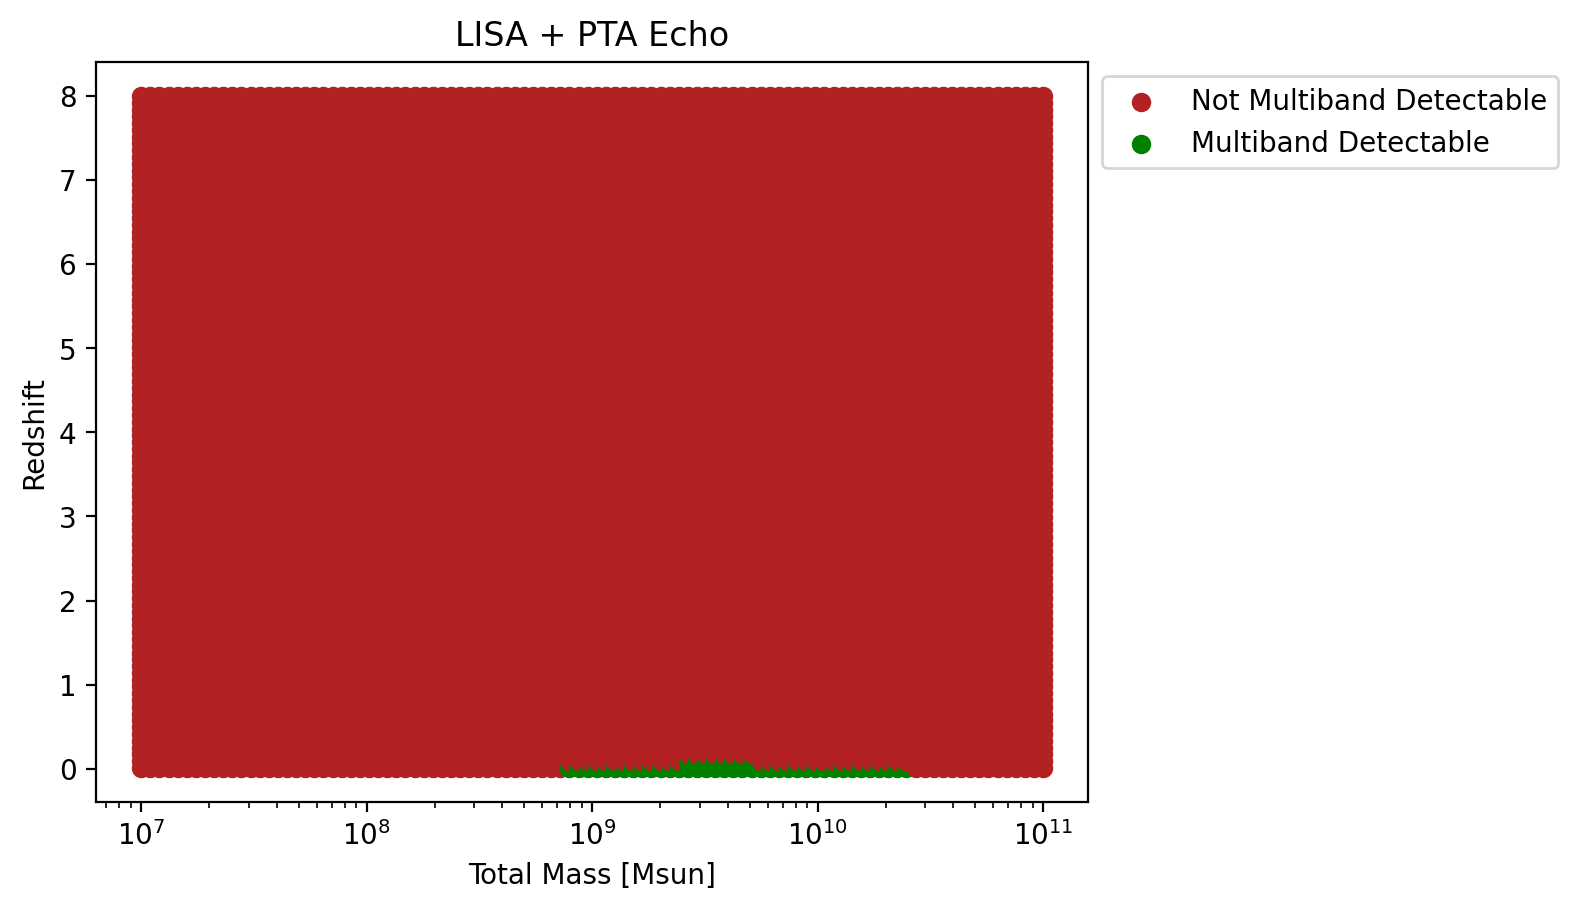

In [122]:
plt.figure()
plt.xscale('log')
rc = 0
gc = 0
for i in range(Nm):
    for j in range(Nz):
        echo_cond = snrs['echo'][i,j] > 3
        merge_cond = np.any([snrs[name][i,j]>merger_snr_min for name in [lisa.name]])
        if echo_cond*merge_cond:
            if gc == 0:
                lab_i = 'Multiband Detectable'
                gc += 1
            else:
                lab_i = '__nolabel__'                
            col_i = 'green'
        else:
            if rc == 0:
                lab_i = 'Not Multiband Detectable'
                rc += 1
            else:
                lab_i = '__nolabel__'   
            col_i = 'firebrick'
        plt.scatter(Mtots[i],zs[j],color=col_i,label=lab_i)
plt.xlabel('Total Mass [Msun]')
plt.ylabel('Redshift')
plt.legend(bbox_to_anchor=(1,1))
plt.title("LISA + PTA Echo")
plt.show()

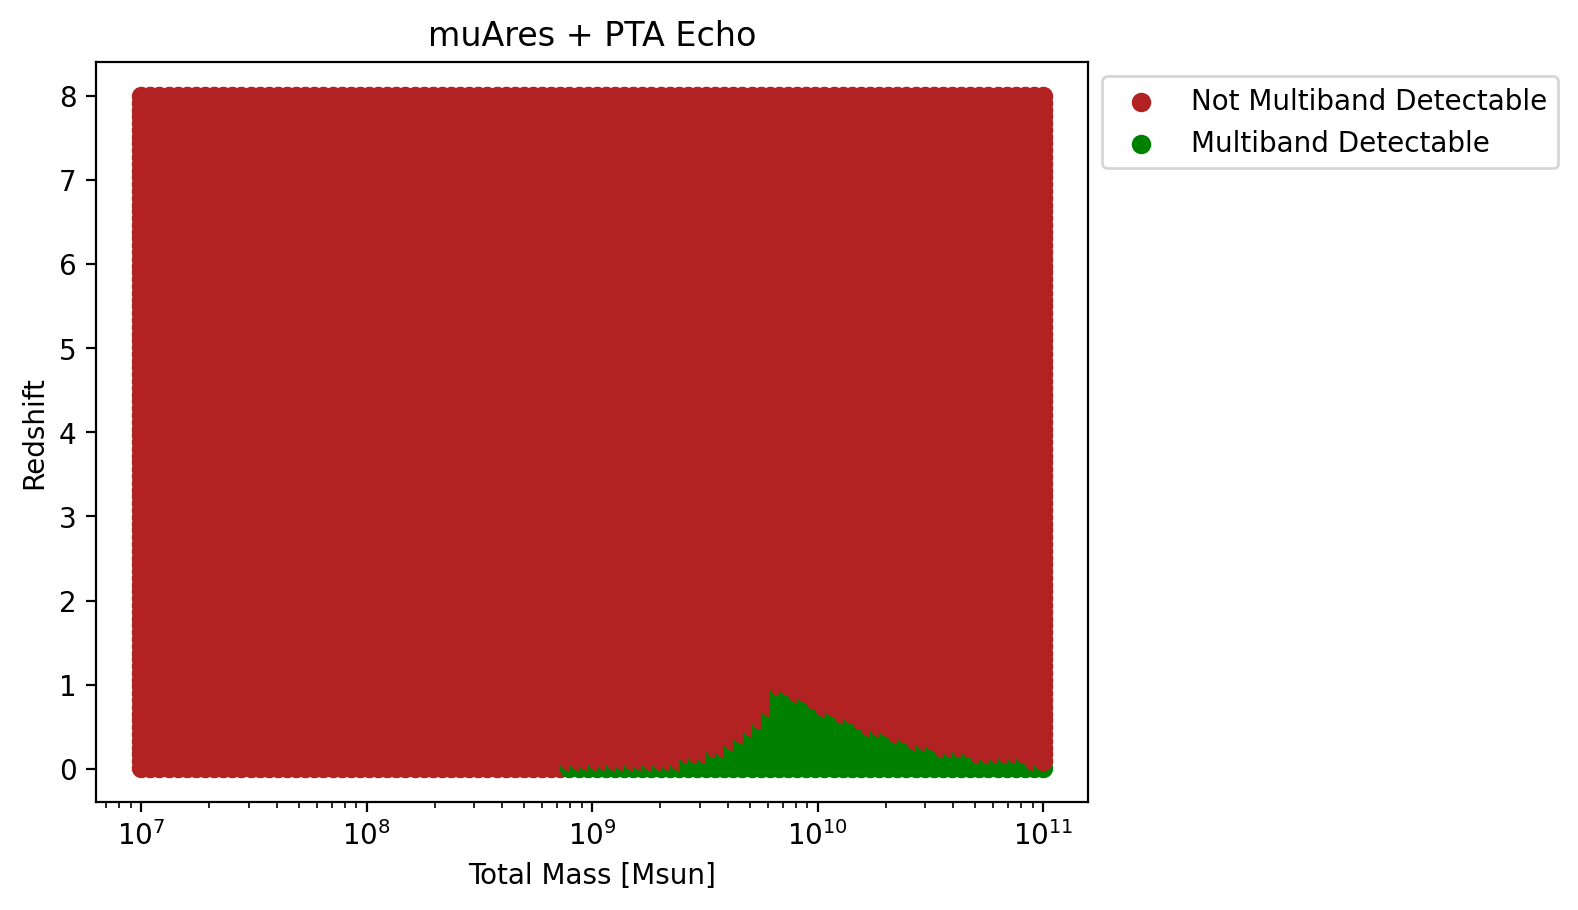

In [123]:
plt.figure()
plt.xscale('log')
rc = 0
gc = 0
for i in range(Nm):
    for j in range(Nz):
        echo_cond = snrs['echo'][i,j] > 3
        merge_cond = np.any([snrs[name][i,j]>merger_snr_min for name in [muAres.name]])
        if echo_cond*merge_cond:
            if gc == 0:
                lab_i = 'Multiband Detectable'
                gc += 1
            else:
                lab_i = '__nolabel__'                
            col_i = 'green'
        else:
            if rc == 0:
                lab_i = 'Not Multiband Detectable'
                rc += 1
            else:
                lab_i = '__nolabel__'   
            col_i = 'firebrick'
        plt.scatter(Mtots[i],zs[j],color=col_i,label=lab_i)
plt.xlabel('Total Mass [Msun]')
plt.ylabel('Redshift')
plt.legend(bbox_to_anchor=(1,1))
plt.title("muAres + PTA Echo")
plt.show()

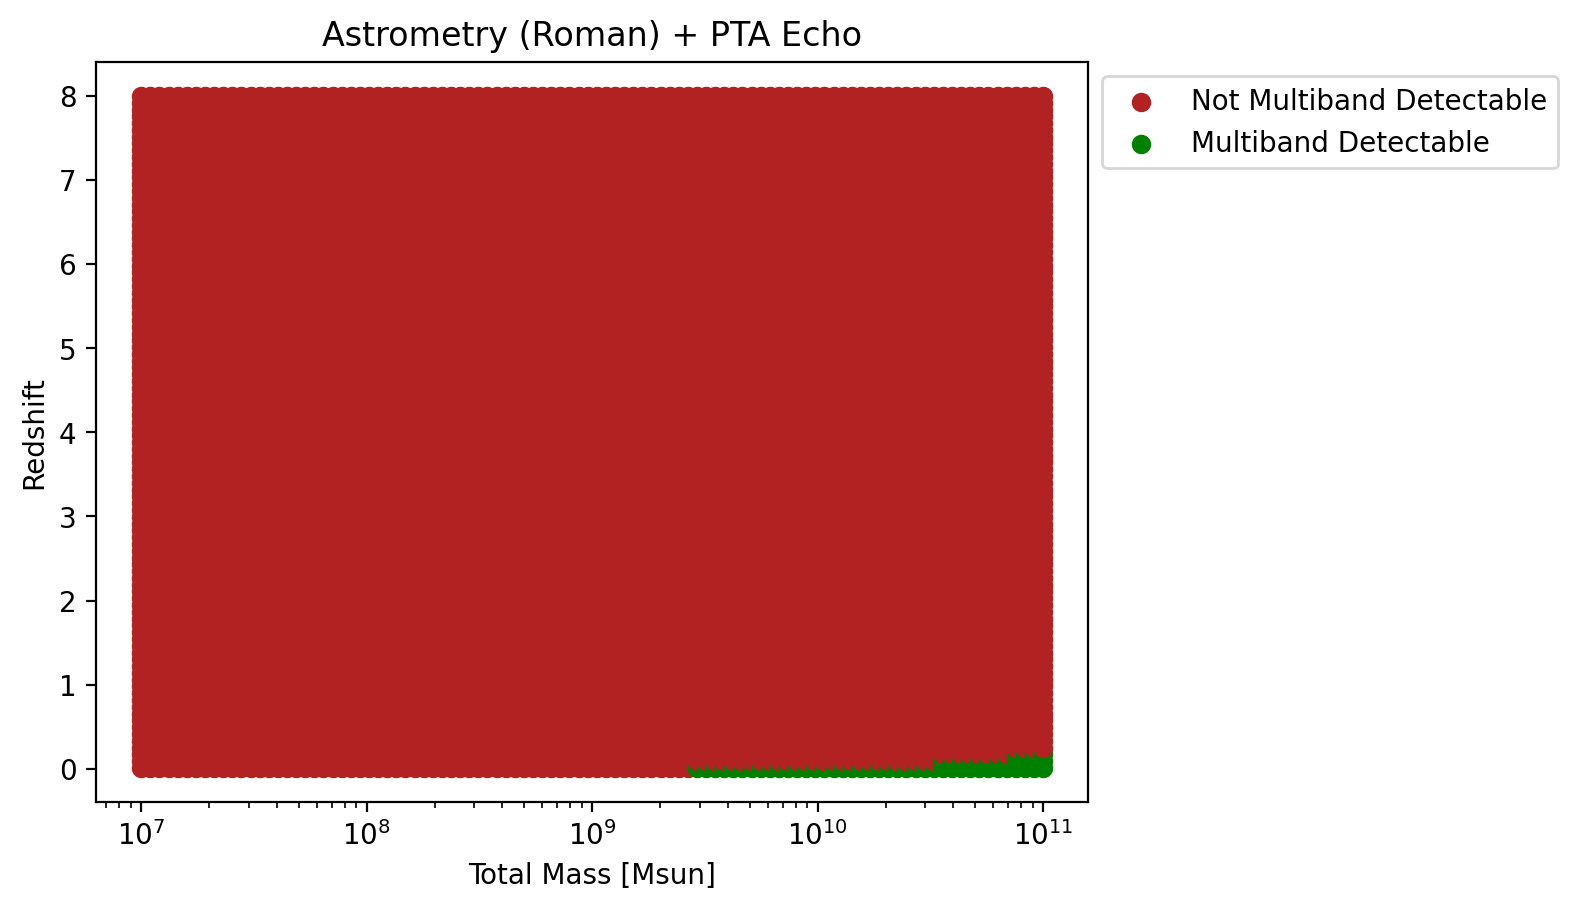

In [124]:
plt.figure()
plt.xscale('log')
rc = 0
gc = 0
for i in range(Nm):
    for j in range(Nz):
        echo_cond = snrs['echo'][i,j] > 3
        merge_cond = np.any([snrs[name][i,j]>merger_snr_min for name in [roman.survey]])
        if echo_cond*merge_cond:
            if gc == 0:
                lab_i = 'Multiband Detectable'
                gc += 1
            else:
                lab_i = '__nolabel__'                
            col_i = 'green'
        else:
            if rc == 0:
                lab_i = 'Not Multiband Detectable'
                rc += 1
            else:
                lab_i = '__nolabel__'   
            col_i = 'firebrick'
        plt.scatter(Mtots[i],zs[j],color=col_i,label=lab_i)
plt.xlabel('Total Mass [Msun]')
plt.ylabel('Redshift')
plt.legend(bbox_to_anchor=(1,1))
plt.title("Astrometry (Roman) + PTA Echo")
plt.show()

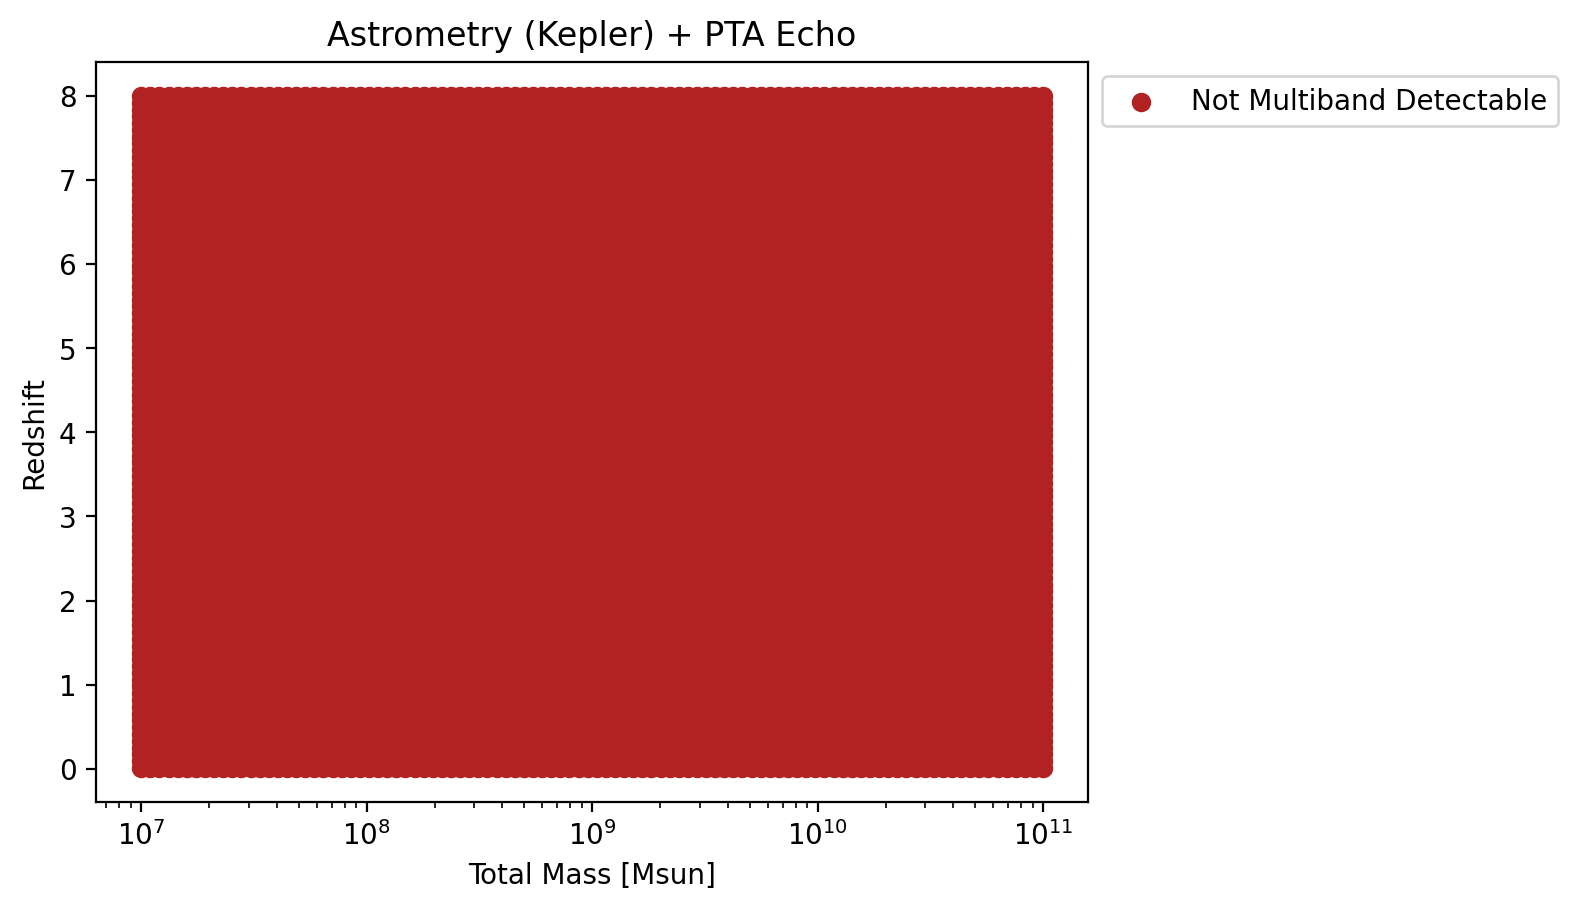

In [125]:
plt.figure()
plt.xscale('log')
rc = 0
gc = 0
for i in range(Nm):
    for j in range(Nz):
        echo_cond = snrs['echo'][i,j] > 3
        merge_cond = np.any([snrs[name][i,j]>merger_snr_min for name in [kepler.survey]])
        if echo_cond*merge_cond:
            if gc == 0:
                lab_i = 'Multiband Detectable'
                gc += 1
            else:
                lab_i = '__nolabel__'                
            col_i = 'green'
        else:
            if rc == 0:
                lab_i = 'Not Multiband Detectable'
                rc += 1
            else:
                lab_i = '__nolabel__'   
            col_i = 'firebrick'
        plt.scatter(Mtots[i],zs[j],color=col_i,label=lab_i)
plt.xlabel('Total Mass [Msun]')
plt.ylabel('Redshift')
plt.legend(bbox_to_anchor=(1,1))
plt.title("Astrometry (Kepler) + PTA Echo")
plt.show()